In [1]:
# ============================================
# CELL 1: IMPORT LIBRARIES (ENGLISH)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix

import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=" * 60)
print("📚 LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)
print(f"✅ Pandas version: {pd.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print(f"✅ Scikit-learn version: {sklearn.__version__}")
print(f"✅ SHAP version: {shap.__version__}")
print("=" * 60)
print("\n🚀 Ready to generate English BAC dataset")
print("=" * 60)

📚 LIBRARIES IMPORTED SUCCESSFULLY
✅ Pandas version: 2.3.3
✅ NumPy version: 2.3.5
✅ Scikit-learn version: 1.8.0
✅ SHAP version: 0.51.0

🚀 Ready to generate English BAC dataset


In [23]:
# ============================================
# CELL 2: GENERATE ENGLISH BAC DATASET (YOUR FEATURES ONLY)
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("📚 GENERATING ENGLISH BAC DATASET")
print(f"Number of students: {n_students}")
print("Target mean: ~13/20")
print("Using ONLY the features you specified")
print("=" * 60)

# ============================================
# STEP 1: Generate Base Ability
# ============================================

base_skill = np.random.normal(6.5, 1.5, n_students)
base_skill = np.clip(base_skill, 3, 9.5)

# ============================================
# A. Reading Skills (5 features)
# ============================================

main_idea_detection = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
inference_skill = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
text_structure = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
ordering_information = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
skimming_scanning = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)

# ============================================
# B. Language Skills (6 features)
# ============================================

synonym_accuracy = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
antonym_accuracy = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
transformation_skill = np.clip(base_skill - 0.3 + np.random.normal(0, 0.9, n_students), 2, 10)
conditional_mastery = np.clip(base_skill - 0.5 + np.random.normal(0, 0.9, n_students), 2, 10)
tense_control = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)
vocabulary_richness = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)

# ============================================
# C. Writing Skills (6 features)
# ============================================

essay_structure = np.clip(base_skill - 0.5 + np.random.normal(0, 0.9, n_students), 2, 10)
guided_writing = np.clip(base_skill - 0.3 + np.random.normal(0, 0.9, n_students), 2, 10)
argumentation_skill = np.clip(base_skill - 0.3 + np.random.normal(0, 0.9, n_students), 2, 10)
coherence_score = np.clip(base_skill - 0.2 + np.random.normal(0, 0.9, n_students), 2, 10)
cohesion_score = np.clip(base_skill - 0.2 + np.random.normal(0, 0.9, n_students), 2, 10)
writing_grammar = np.clip(base_skill + np.random.normal(0, 0.8, n_students), 3, 10)

# ============================================
# D. Practice & Habits
# ============================================

reading_frequency = np.random.choice([0,1,2,3,4,5,6,7,8,9,10], n_students, p=[0.05,0.05,0.1,0.1,0.15,0.15,0.15,0.1,0.05,0.05,0.05])
writing_frequency = np.random.choice([0,1,2,3,4,5], n_students, p=[0.05,0.1,0.3,0.3,0.15,0.1])
past_exam_practice = np.random.poisson(5, n_students)
past_exam_practice = np.clip(past_exam_practice, 0, 20)
study_hours = np.random.normal(5, 2, n_students)
study_hours = np.clip(study_hours, 2, 12)
study_hours = np.round(study_hours, 1)
consistency = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.2,0.35,0.3])
study_method = np.random.choice([0,1,2], n_students, p=[0.4,0.35,0.25])
class_participation = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.25,0.35,0.25])
tutoring = np.random.choice([0,1], n_students, p=[0.7,0.3])

# ============================================
# E. Psychological Factors
# ============================================

confidence = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.3,0.35,0.2])
stress = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.25,0.35,0.25])
motivation = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.25,0.35,0.25])

# ============================================
# F. Filière
# ============================================

filiere = np.random.choice([0, 1, 2], n_students, p=[0.5, 0.3, 0.2])

# ============================================
# G. Academic History (Trimester Grades)
# ============================================

# Generate avg_grade from skills
avg_grade = (
    0.15 * main_idea_detection +
    0.10 * inference_skill +
    0.10 * transformation_skill +
    0.10 * essay_structure +
    0.10 * (past_exam_practice / 2) +
    0.05 * reading_frequency +
    0.05 * writing_frequency
) * 2

avg_grade = np.clip(avg_grade, 8, 19.5)
avg_grade = np.round(avg_grade, 1)

# Generate trimester grades
grade_t1 = avg_grade + np.random.normal(-0.5, 1.0, n_students)
grade_t2 = avg_grade + np.random.normal(0, 0.9, n_students)
grade_t3 = avg_grade + np.random.normal(0.5, 0.8, n_students)

grade_t1 = np.clip(grade_t1, 8, 19.5)
grade_t2 = np.clip(grade_t2, 8, 19.5)
grade_t3 = np.clip(grade_t3, 8, 19.5)

grade_t1 = np.round(grade_t1, 1)
grade_t2 = np.round(grade_t2, 1)
grade_t3 = np.round(grade_t3, 1)

grade_trend = grade_t3 - grade_t1
grade_trend = np.round(grade_trend, 1)

# ============================================
# H. Calculate BAC Score
# ============================================

# Scale practice features
past_exam_scaled = (past_exam_practice / 20) * 10
reading_freq_scaled = (reading_frequency / 10) * 10
writing_freq_scaled = (writing_frequency / 5) * 10

bac_score = (
    # Reading Skills
    0.12 * main_idea_detection +
    0.10 * inference_skill +
    0.08 * text_structure +
    0.08 * ordering_information +
    0.07 * skimming_scanning +
    
    # Language Skills
    0.07 * synonym_accuracy +
    0.07 * antonym_accuracy +
    0.08 * transformation_skill +
    0.07 * conditional_mastery +
    0.06 * tense_control +
    0.06 * vocabulary_richness +
    
    # Writing Skills
    0.06 * essay_structure +
    0.05 * guided_writing +
    0.05 * argumentation_skill +
    0.05 * coherence_score +
    0.05 * cohesion_score +
    0.05 * writing_grammar +
    
    # Practice (past exams have highest weight)
    0.08 * past_exam_scaled +
    0.03 * reading_freq_scaled +
    0.03 * writing_freq_scaled +
    0.02 * (study_hours / 6) +
    0.02 * (consistency / 5) * 10 +
    0.01 * class_participation +
    0.01 * (tutoring * 10)
) * 1.2

# Add psychological adjustments
bac_score = bac_score + (confidence - 3) * 0.1 - (stress - 3) * 0.05

# Add noise and adjust mean
bac_score = bac_score + np.random.normal(0, 0.4, n_students)
current_mean = bac_score.mean()
bac_score = bac_score * (13.0 / current_mean)
bac_score = np.clip(bac_score, 8, 19.5)
bac_score = np.round(bac_score, 1)

# ============================================
# Round all skills
# ============================================

main_idea_detection = np.round(main_idea_detection, 1)
inference_skill = np.round(inference_skill, 1)
text_structure = np.round(text_structure, 1)
ordering_information = np.round(ordering_information, 1)
skimming_scanning = np.round(skimming_scanning, 1)

synonym_accuracy = np.round(synonym_accuracy, 1)
antonym_accuracy = np.round(antonym_accuracy, 1)
transformation_skill = np.round(transformation_skill, 1)
conditional_mastery = np.round(conditional_mastery, 1)
tense_control = np.round(tense_control, 1)
vocabulary_richness = np.round(vocabulary_richness, 1)

essay_structure = np.round(essay_structure, 1)
guided_writing = np.round(guided_writing, 1)
argumentation_skill = np.round(argumentation_skill, 1)
coherence_score = np.round(coherence_score, 1)
cohesion_score = np.round(cohesion_score, 1)
writing_grammar = np.round(writing_grammar, 1)

# ============================================
# Create DataFrame (ONLY your features)
# ============================================

df = pd.DataFrame({
    # Academic History
    'grade_t1': grade_t1,
    'grade_t2': grade_t2,
    'grade_t3': grade_t3,
    'avg_grade': avg_grade,
    'grade_trend': grade_trend,
    
    # Reading Skills
    'main_idea_detection': main_idea_detection,
    'inference_skill': inference_skill,
    'text_structure': text_structure,
    'ordering_information': ordering_information,
    'skimming_scanning': skimming_scanning,
    
    # Language Skills
    'synonym_accuracy': synonym_accuracy,
    'antonym_accuracy': antonym_accuracy,
    'transformation_skill': transformation_skill,
    'conditional_mastery': conditional_mastery,
    'tense_control': tense_control,
    'vocabulary_richness': vocabulary_richness,
    
    # Writing Skills
    'essay_structure': essay_structure,
    'guided_writing': guided_writing,
    'argumentation_skill': argumentation_skill,
    'coherence_score': coherence_score,
    'cohesion_score': cohesion_score,
    'writing_grammar': writing_grammar,
    
    # Practice & Habits
    'reading_frequency': reading_frequency,
    'writing_frequency': writing_frequency,
    'past_exam_practice': past_exam_practice,
    'study_hours': study_hours,
    'consistency': consistency,
    'study_method': study_method,
    'class_participation': class_participation,
    'tutoring': tutoring,
    
    # Psychological
    'confidence': confidence,
    'stress': stress,
    'motivation': motivation,
    
    # Context
    'filiere': filiere,
    
    # Target
    'bac_score': bac_score
})

print("\n✅ Dataset generated successfully!")
print(f"   Students: {df.shape[0]}")
print(f"   Features: {df.shape[1]}")
print(f"\n📊 BAC Score Statistics:")
print(f"   Mean: {df['bac_score'].mean():.2f}/20")
print(f"   Min: {df['bac_score'].min():.1f}/20")
print(f"   Max: {df['bac_score'].max():.1f}/20")
print(f"   Std: {df['bac_score'].std():.2f}")

print("\n📊 BAC Score Distribution:")
print(f"   8-10:   {((df['bac_score'] >= 8) & (df['bac_score'] < 11)).sum()} students")
print(f"   11-12:  {((df['bac_score'] >= 11) & (df['bac_score'] < 13)).sum()} students")
print(f"   13-14:  {((df['bac_score'] >= 13) & (df['bac_score'] < 15)).sum()} students")
print(f"   15-16:  {((df['bac_score'] >= 15) & (df['bac_score'] < 17)).sum()} students")
print(f"   17-19:  {(df['bac_score'] >= 17).sum()} students")

print("\n📊 Correlations with BAC Score:")
print(f"   past_exam_practice: {df['bac_score'].corr(df['past_exam_practice']):.3f}")
print(f"   transformation_skill: {df['bac_score'].corr(df['transformation_skill']):.3f}")
print(f"   main_idea_detection: {df['bac_score'].corr(df['main_idea_detection']):.3f}")
print(f"   essay_structure: {df['bac_score'].corr(df['essay_structure']):.3f}")
print(f"   avg_grade: {df['bac_score'].corr(df['avg_grade']):.3f}")

print("\n📊 First 5 rows:")
print(df.head())

📚 GENERATING ENGLISH BAC DATASET
Number of students: 500
Target mean: ~13/20
Using ONLY the features you specified

✅ Dataset generated successfully!
   Students: 500
   Features: 35

📊 BAC Score Statistics:
   Mean: 13.01/20
   Min: 8.0/20
   Max: 19.4/20
   Std: 2.60

📊 BAC Score Distribution:
   8-10:   111 students
   11-12:  139 students
   13-14:  131 students
   15-16:  75 students
   17-19:  44 students

📊 Correlations with BAC Score:
   past_exam_practice: 0.059
   transformation_skill: 0.840
   main_idea_detection: 0.870
   essay_structure: 0.825
   avg_grade: 0.624

📊 First 5 rows:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  main_idea_detection  inference_skill  text_structure  ordering_information  skimming_scanning  synonym_accuracy  antonym_accuracy  transformation_skill  conditional_mastery  tense_control  vocabulary_richness  essay_structure  guided_writing  argumentation_skill  coherence_score  cohesion_score  writing_grammar  reading_frequency  writing_fr

In [24]:
# ============================================
# CELL 3: SAVE DATASET (ENGLISH)
# ============================================

# Save the dataset to CSV file
csv_filename = 'english_bac_dataset.csv'

df.to_csv(csv_filename, index=False)

print("=" * 60)
print("💾 DATASET SAVED SUCCESSFULLY")
print("=" * 60)
print(f"   File: {csv_filename}")
print(f"   Students: {df.shape[0]}")
print(f"   Features: {df.shape[1]}")
print("=" * 60)

# Display file size
import os
file_size = os.path.getsize(csv_filename)
print(f"   File size: {file_size / 1024:.2f} KB")
print("=" * 60)

print("\n📊 Preview of saved data (first 3 rows):")
print(df.head(3))

print("\n📊 Column names:")
print(df.columns.tolist())

💾 DATASET SAVED SUCCESSFULLY
   File: english_bac_dataset.csv
   Students: 500
   Features: 35
   File size: 59.35 KB

📊 Preview of saved data (first 3 rows):
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  main_idea_detection  inference_skill  text_structure  ordering_information  skimming_scanning  synonym_accuracy  antonym_accuracy  transformation_skill  conditional_mastery  tense_control  vocabulary_richness  essay_structure  guided_writing  argumentation_skill  coherence_score  cohesion_score  writing_grammar  reading_frequency  writing_frequency  past_exam_practice  study_hours  consistency  study_method  class_participation  tutoring  confidence  stress  motivation  filiere  bac_score
0       8.0       8.0       9.3        8.0          1.3                  8.0              8.4             7.9                   6.7                7.7               5.7               8.2                   6.2                  5.9            6.9                  7.8              5.7        

In [2]:
# ============================================
# CELL 4: LOAD DATASET (ENGLISH)
# ============================================

# Load the dataset from CSV file
csv_filename = 'english_bac_dataset.csv'

df = pd.read_csv(csv_filename)

print("=" * 60)
print("📂 DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"   File: {csv_filename}")
print(f"   Students: {df.shape[0]}")
print(f"   Features: {df.shape[1]}")
print("=" * 60)

print("\n📊 Quick statistics:")
print(f"   BAC Score - Mean: {df['bac_score'].mean():.2f}/20")
print(f"   BAC Score - Min: {df['bac_score'].min():.1f}/20")
print(f"   BAC Score - Max: {df['bac_score'].max():.1f}/20")
print(f"   BAC Score - Std: {df['bac_score'].std():.2f}")

print("\n📊 First 3 rows:")
print(df.head(3))

print("\n📊 Column names:")
print(df.columns.tolist())

📂 DATASET LOADED SUCCESSFULLY
   File: english_bac_dataset.csv
   Students: 500
   Features: 35

📊 Quick statistics:
   BAC Score - Mean: 13.01/20
   BAC Score - Min: 8.0/20
   BAC Score - Max: 19.4/20
   BAC Score - Std: 2.60

📊 First 3 rows:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  main_idea_detection  inference_skill  text_structure  ordering_information  skimming_scanning  synonym_accuracy  antonym_accuracy  transformation_skill  conditional_mastery  tense_control  vocabulary_richness  essay_structure  guided_writing  argumentation_skill  coherence_score  cohesion_score  writing_grammar  reading_frequency  writing_frequency  past_exam_practice  study_hours  consistency  study_method  class_participation  tutoring  confidence  stress  motivation  filiere  bac_score
0       8.0       8.0       9.3        8.0          1.3                  8.0              8.4             7.9                   6.7                7.7               5.7               8.2                   

In [3]:
# ============================================
# CELL 5: EDA - OVERVIEW (ENGLISH)
# ============================================

print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS - OVERVIEW")
print("=" * 60)

# 1. First 5 rows
print("\n📋 FIRST 5 ROWS:")
print(df.head())

# 2. Last 5 rows
print("\n📋 LAST 5 ROWS:")
print(df.tail())

# 3. Dataset info
print("\n📋 DATASET INFO:")
print(df.info())

# 4. Summary statistics
print("\n📋 SUMMARY STATISTICS:")
print(df.describe().round(2))

# 5. Missing values check
print("\n📋 MISSING VALUES:")
missing = df.isnull().sum().sum()
if missing == 0:
    print("   ✅ No missing values")
else:
    print(f"   ⚠️ {missing} missing values found")

# 6. Duplicate rows check
print("\n📋 DUPLICATE ROWS:")
duplicates = df.duplicated().sum()
if duplicates == 0:
    print("   ✅ No duplicate rows")
else:
    print(f"   ⚠️ {duplicates} duplicate rows found")

# 7. Data types summary
print("\n📋 DATA TYPES SUMMARY:")
print(df.dtypes.value_counts())

# 8. Dataset shape
print("\n📋 DATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# 9. Memory usage
print("\n📋 MEMORY USAGE:")
print(f"   {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# 10. Column names list
print("\n📋 ALL COLUMN NAMES:")
print(df.columns.tolist())

print("\n" + "=" * 60)
print("✅ EDA OVERVIEW COMPLETE")
print("=" * 60)

📊 EXPLORATORY DATA ANALYSIS - OVERVIEW

📋 FIRST 5 ROWS:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  main_idea_detection  inference_skill  text_structure  ordering_information  skimming_scanning  synonym_accuracy  antonym_accuracy  transformation_skill  conditional_mastery  tense_control  vocabulary_richness  essay_structure  guided_writing  argumentation_skill  coherence_score  cohesion_score  writing_grammar  reading_frequency  writing_frequency  past_exam_practice  study_hours  consistency  study_method  class_participation  tutoring  confidence  stress  motivation  filiere  bac_score
0       8.0       8.0       9.3        8.0          1.3                  8.0              8.4             7.9                   6.7                7.7               5.7               8.2                   6.2                  5.9            6.9                  7.8              5.7             8.0                  7.7              8.6             7.0              9.2                  7     

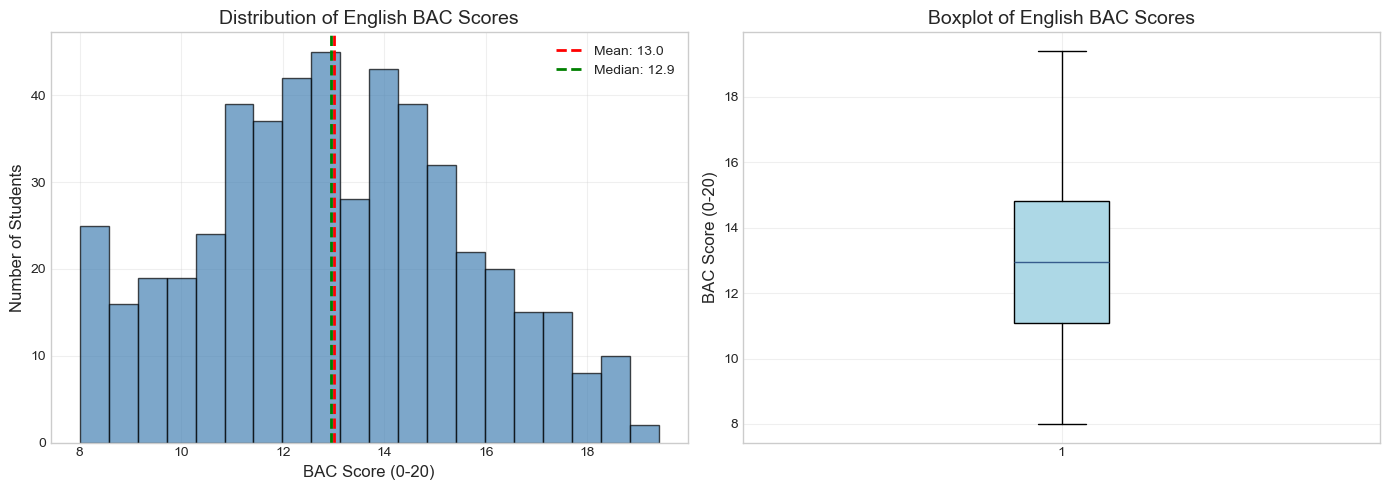


📊 BAC SCORE STATISTICS
   Mean:     13.01
   Median:   12.95
   Mode:     14.10
   Std Dev:  2.60
   Min:      8.0
   Max:      19.4
   Range:    11.4

📊 PERCENTILES:
   10th percentile: 9.50
   25th percentile: 11.10
   50th percentile: 12.95
   75th percentile: 14.80
   90th percentile: 16.51

📊 SCORE DISTRIBUTION BY RANGE:
    8 - 10:  67 students ( 13.4%) ██████
   10 - 12: 112 students ( 22.4%) ███████████
   12 - 14: 136 students ( 27.2%) █████████████
   14 - 16: 115 students ( 23.0%) ███████████
   16 - 18:  56 students ( 11.2%) █████
   18 - 20:  14 students (  2.8%) █

📊 PASSING RATE (score ≥ 10): 86.6%
📊 EXCELLENCE RATE (score ≥ 16): 14.0%

✅ BAC SCORE DISTRIBUTION COMPLETE


In [4]:
# ============================================
# CELL 6: EDA - BAC SCORE DISTRIBUTION (ENGLISH)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 2 graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Histogram
axes[0].hist(df['bac_score'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(df['bac_score'].mean(), color='red', linestyle='dashed', linewidth=2, 
                label=f'Mean: {df["bac_score"].mean():.1f}')
axes[0].axvline(df['bac_score'].median(), color='green', linestyle='dashed', linewidth=2, 
                label=f'Median: {df["bac_score"].median():.1f}')
axes[0].set_xlabel('BAC Score (0-20)', fontsize=12)
axes[0].set_ylabel('Number of Students', fontsize=12)
axes[0].set_title('Distribution of English BAC Scores', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graph 2: Boxplot
boxplot = axes[1].boxplot(df['bac_score'], vert=True, patch_artist=True)
boxplot['boxes'][0].set_facecolor('lightblue')
axes[1].set_ylabel('BAC Score (0-20)', fontsize=12)
axes[1].set_title('Boxplot of English BAC Scores', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed statistics
print("\n" + "=" * 60)
print("📊 BAC SCORE STATISTICS")
print("=" * 60)
print(f"   Mean:     {df['bac_score'].mean():.2f}")
print(f"   Median:   {df['bac_score'].median():.2f}")
print(f"   Mode:     {df['bac_score'].mode().values[0]:.2f}")
print(f"   Std Dev:  {df['bac_score'].std():.2f}")
print(f"   Min:      {df['bac_score'].min():.1f}")
print(f"   Max:      {df['bac_score'].max():.1f}")
print(f"   Range:    {df['bac_score'].max() - df['bac_score'].min():.1f}")

# Percentiles
print("\n📊 PERCENTILES:")
for p in [10, 25, 50, 75, 90]:
    print(f"   {p}th percentile: {df['bac_score'].quantile(p/100):.2f}")

# Distribution by range
print("\n📊 SCORE DISTRIBUTION BY RANGE:")
ranges = [(8, 10), (10, 12), (12, 14), (14, 16), (16, 18), (18, 20)]
for low, high in ranges:
    count = ((df['bac_score'] >= low) & (df['bac_score'] < high)).sum()
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"   {low:2d} - {high:2d}: {count:3d} students ({pct:5.1f}%) {bar}")

# Passing rate
passing_rate = (df['bac_score'] >= 10).mean() * 100
print(f"\n📊 PASSING RATE (score ≥ 10): {passing_rate:.1f}%")

# Excellence rate
excellence_rate = (df['bac_score'] >= 16).mean() * 100
print(f"📊 EXCELLENCE RATE (score ≥ 16): {excellence_rate:.1f}%")

print("\n" + "=" * 60)
print("✅ BAC SCORE DISTRIBUTION COMPLETE")
print("=" * 60)


📊 CORRELATION WITH BAC SCORE
(Highest to lowest)
---------------------------------------------
   bac_score                     : 1.000
   text_structure                : 0.872
   main_idea_detection           : 0.870
   skimming_scanning             : 0.860
   ordering_information          : 0.860
   inference_skill               : 0.855
   tense_control                 : 0.852
   writing_grammar               : 0.851
   vocabulary_richness           : 0.851
   antonym_accuracy              : 0.847
   synonym_accuracy              : 0.847
   argumentation_skill           : 0.847
   transformation_skill          : 0.840
   conditional_mastery           : 0.826
   essay_structure               : 0.825
   coherence_score               : 0.812
   guided_writing                : 0.810
   cohesion_score                : 0.806
   avg_grade                     : 0.624
   grade_t3                      : 0.370
   grade_t2                      : 0.278
   grade_t1                      : 0.243
  

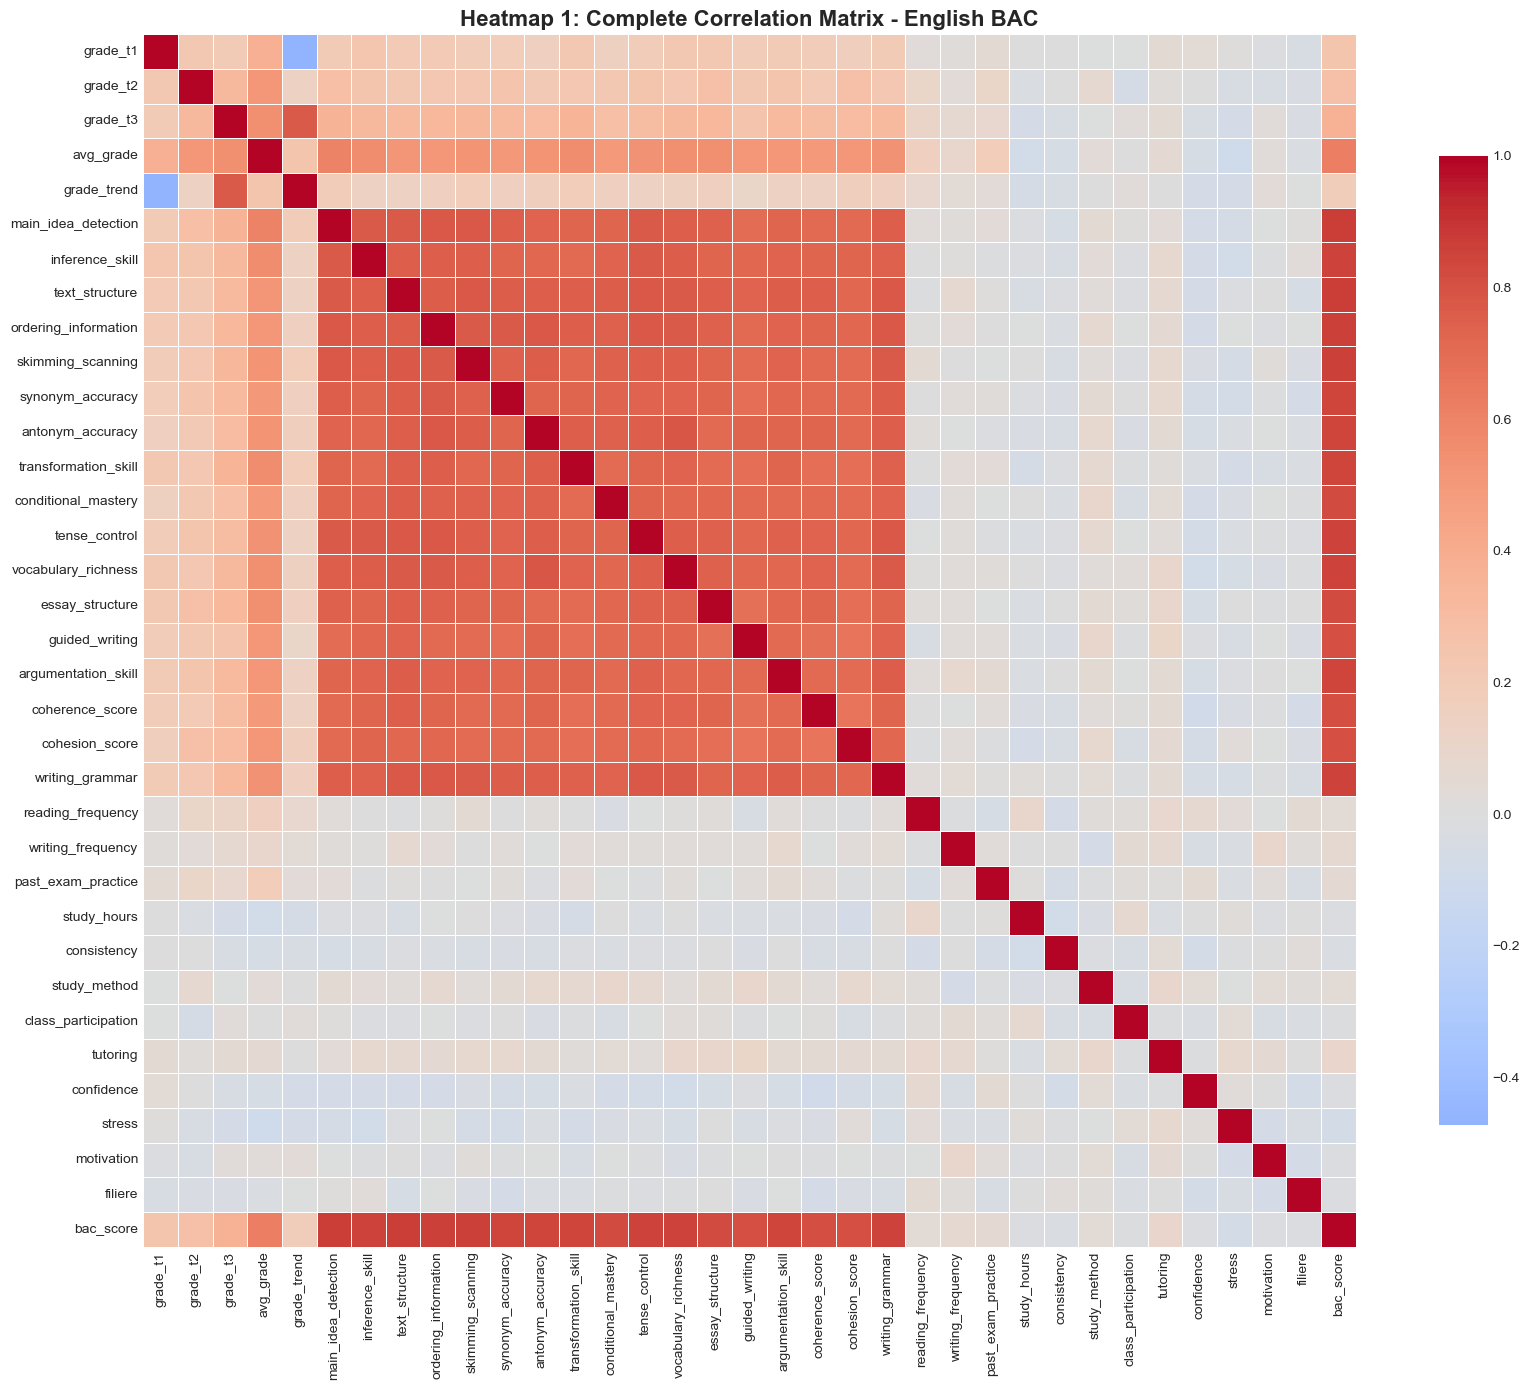


📊 HEATMAP 2: Top 15 Features Correlated with BAC Score


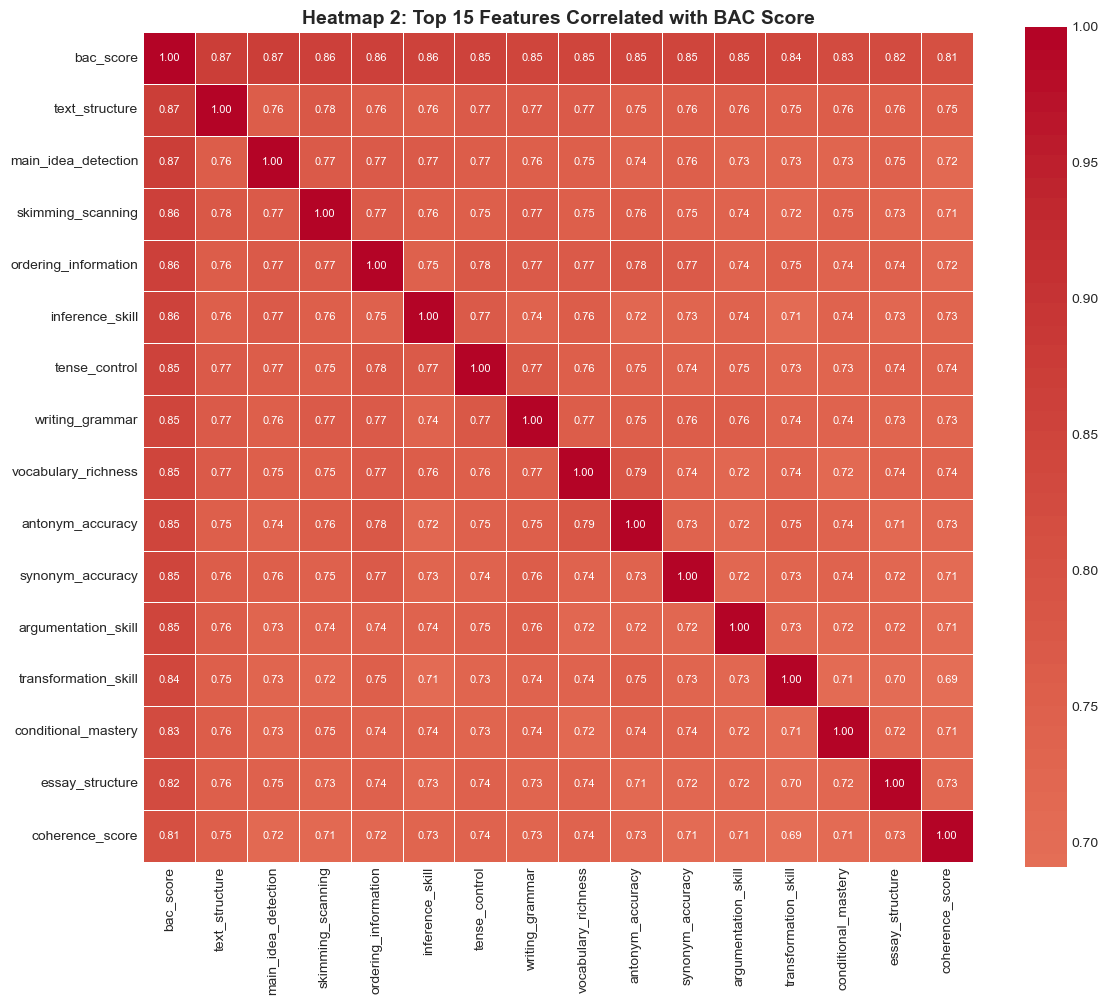


📊 HEATMAP 3: Reading, Language, Writing Scores Correlation


KeyError: "['reading_score', 'language_score', 'writing_score'] not in index"

In [5]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS (ENGLISH)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Correlation with BAC score
bac_corr = corr_matrix['bac_score'].sort_values(ascending=False)
print("\n" + "=" * 60)
print("📊 CORRELATION WITH BAC SCORE")
print("=" * 60)
print("(Highest to lowest)")
print("-" * 45)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:30s}: {corr_value:.3f}")

# ============================================
# HEATMAP 1: All Features
# ============================================
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap 1: Complete Correlation Matrix - English BAC', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 2: Top 15 Features Correlated with BAC
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 2: Top 15 Features Correlated with BAC Score")
print("=" * 60)

# Get top 15 features (including bac_score itself)
top_features = bac_corr.head(16).index.tolist()
corr_top = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_top, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap 2: Top 15 Features Correlated with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 3: Reading, Language, Writing Scores
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 3: Reading, Language, Writing Scores Correlation")
print("=" * 60)

# Focus on the three main skill scores
skill_scores = ['reading_score', 'language_score', 'writing_score', 'bac_score']
corr_skills = df[skill_scores].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_skills, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.3f',
            linewidths=1,
            annot_kws={'size': 11})
plt.title('Heatmap 3: Reading, Language, Writing Scores Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 4: Remaining Features (Low Correlation)
# ============================================
print("\n" + "=" * 60)
print("📊 HEATMAP 4: Remaining Features (Low Correlation with BAC)")
print("=" * 60)

top_feature_names = bac_corr.head(16).index.tolist()
remaining_features = [f for f in numeric_cols if f not in top_feature_names and f != 'bac_score']

if len(remaining_features) > 0:
    corr_remaining = df[remaining_features].corr()
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_remaining, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 7})
    plt.title('Heatmap 4: Remaining Features (Lower Correlation with BAC)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n📋 Remaining features ({len(remaining_features)} features):")
    for f in remaining_features[:20]:  # Show first 20
        print(f"   • {f}: correlation = {bac_corr[f]:.3f}")
    if len(remaining_features) > 20:
        print(f"   ... and {len(remaining_features)-20} more")
else:
    print("   No remaining features to display")

print("\n" + "=" * 60)
print("✅ CORRELATION HEATMAPS COMPLETE")
print("=" * 60)

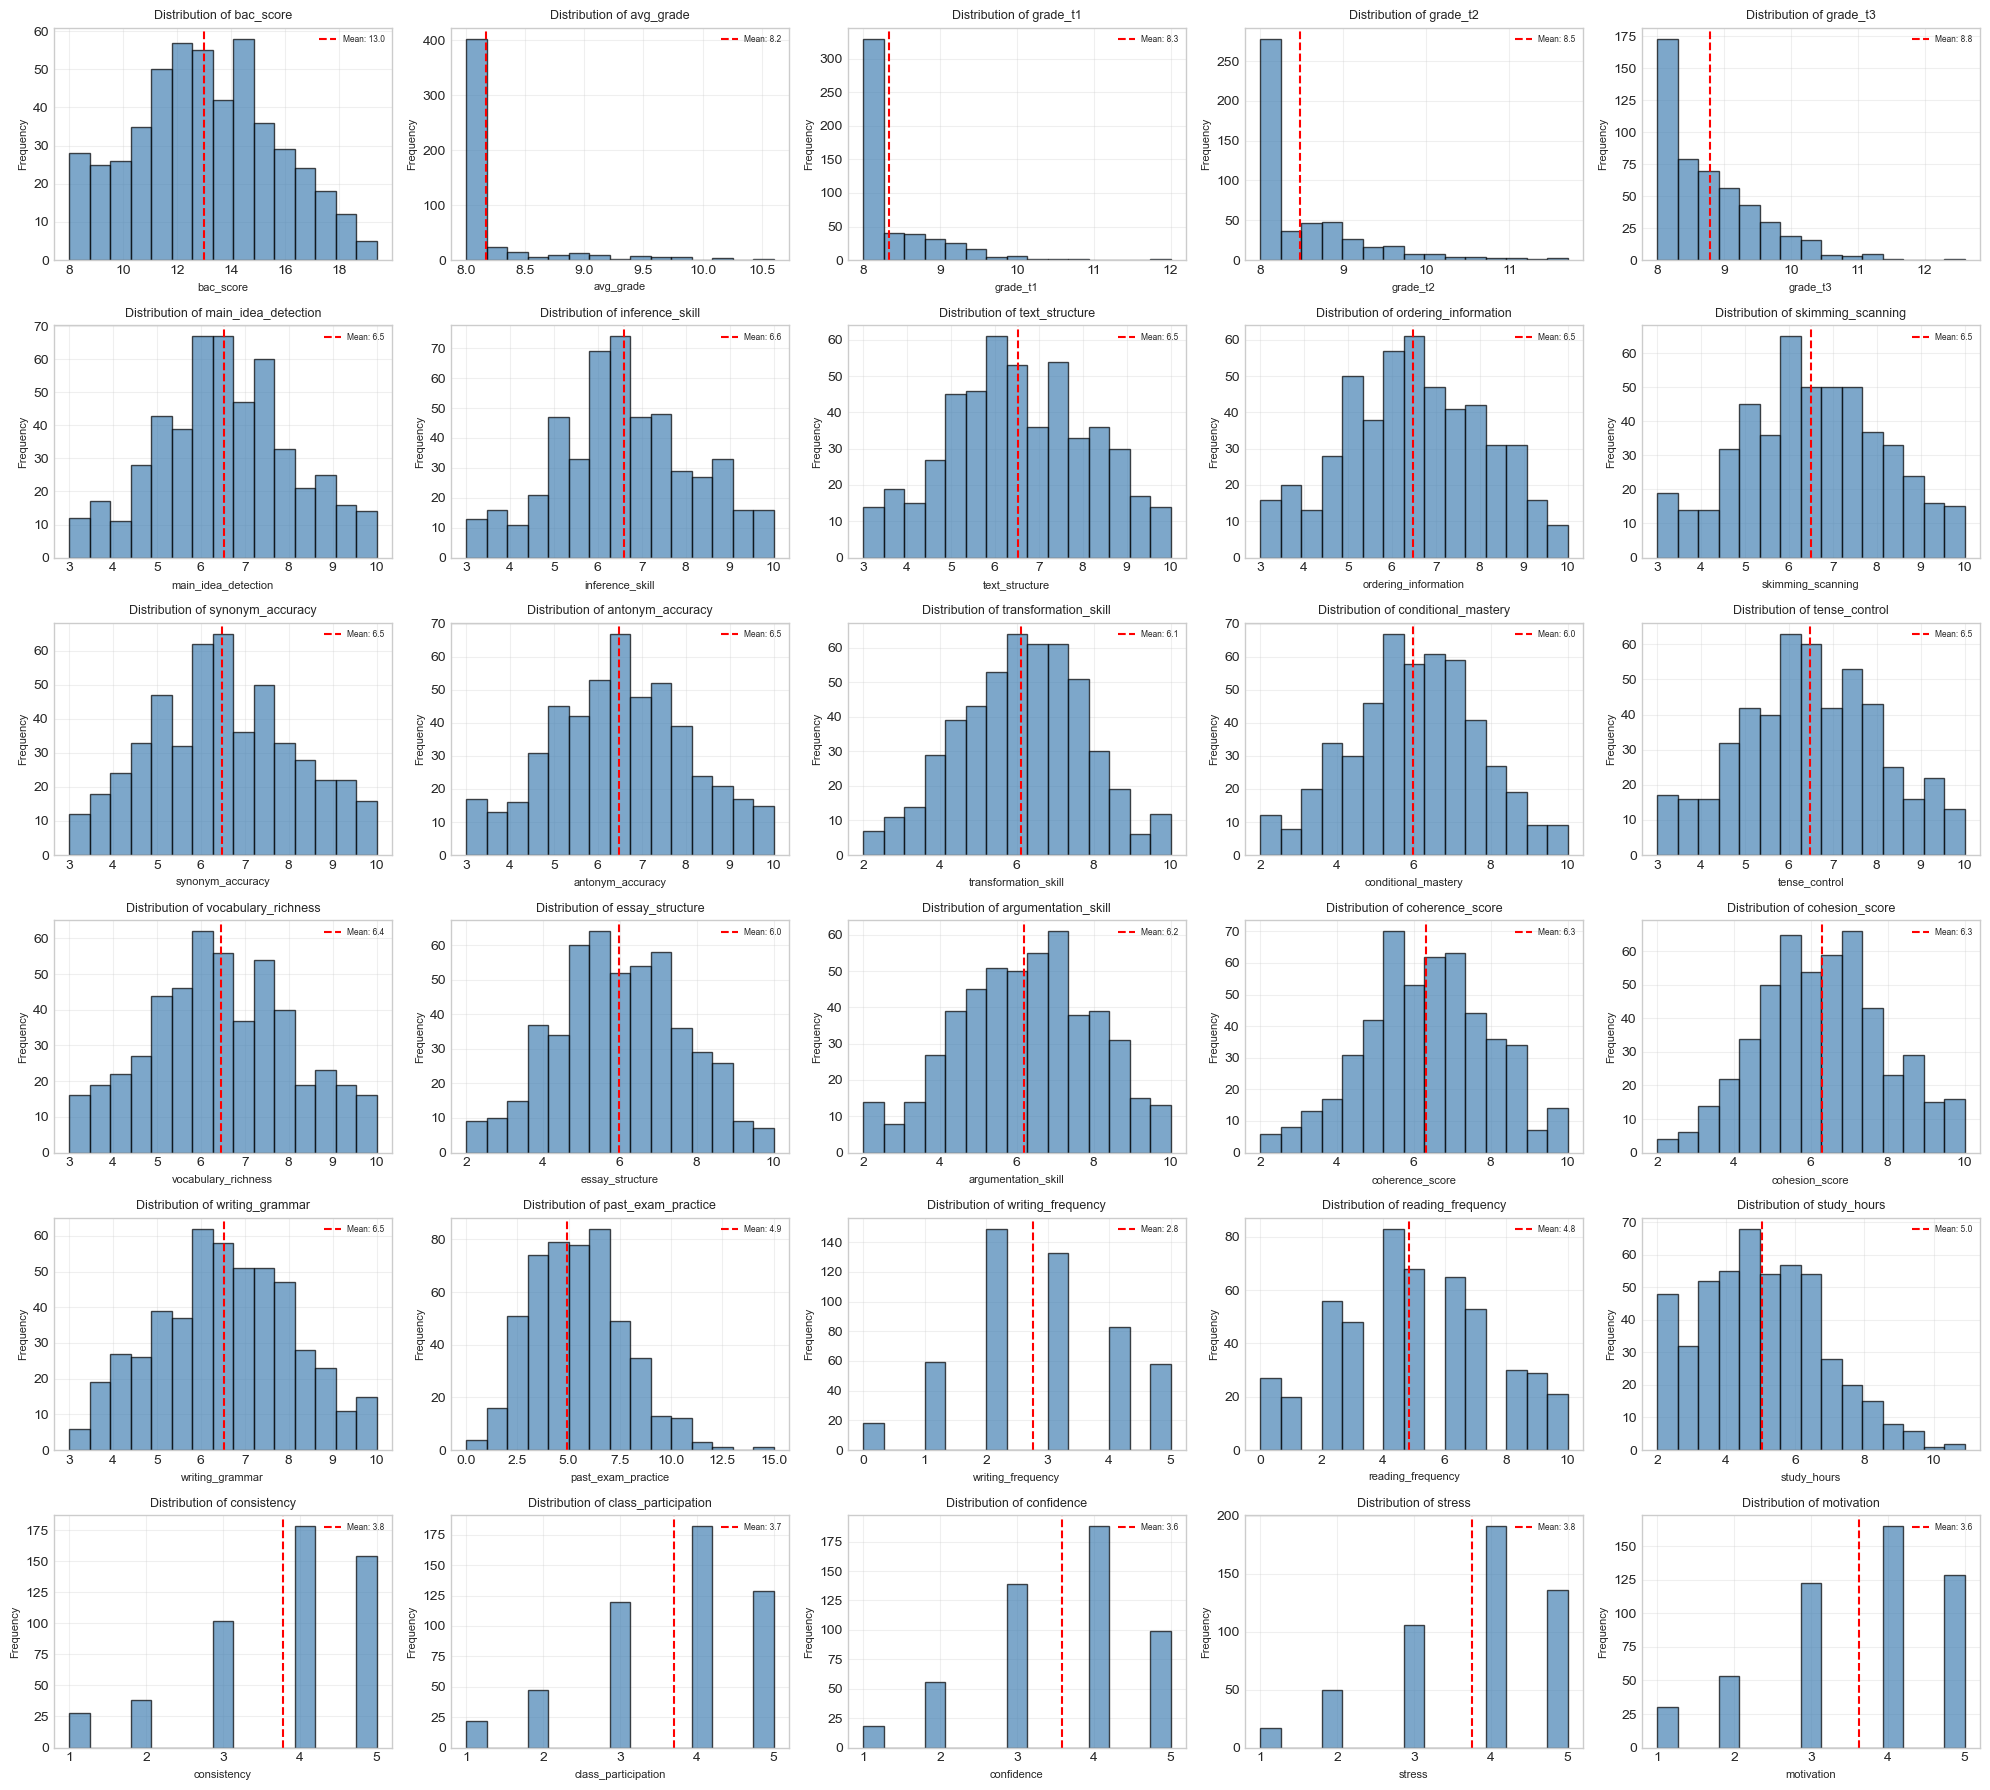


📊 SUMMARY STATISTICS FOR KEY FEATURES
       bac_score  avg_grade  main_idea_detection  inference_skill  transformation_skill  conditional_mastery  essay_structure  argumentation_skill  past_exam_practice  writing_frequency  reading_frequency  study_hours  consistency  confidence  stress  motivation
count     500.00     500.00               500.00           500.00                500.00               500.00           500.00               500.00              500.00             500.00             500.00       500.00       500.00      500.00  500.00      500.00
mean       13.01       8.17                 6.52             6.58                  6.11                 5.99             5.97                 6.20                4.94               2.76               4.84         5.02         3.78        3.59    3.76        3.62
std         2.60       0.43                 1.54             1.56                  1.63                 1.66             1.66                 1.76                2.26      

In [6]:
# ============================================
# CELL 8: EDA - FEATURE DISTRIBUTIONS (ENGLISH - UPDATED)
# ============================================

import matplotlib.pyplot as plt

# Select key features to visualize (ONLY features that exist in your dataset)
key_features = [
    'bac_score', 'avg_grade', 'grade_t1', 'grade_t2', 'grade_t3',
    'main_idea_detection', 'inference_skill', 'text_structure', 'ordering_information', 'skimming_scanning',
    'synonym_accuracy', 'antonym_accuracy', 'transformation_skill', 'conditional_mastery', 
    'tense_control', 'vocabulary_richness',
    'essay_structure', 'argumentation_skill', 'coherence_score', 'cohesion_score', 'writing_grammar',
    'past_exam_practice', 'writing_frequency', 'reading_frequency',
    'study_hours', 'consistency', 'class_participation',
    'confidence', 'stress', 'motivation'
]

# Create subplots
fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if feature in df.columns:
        axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
        axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                        label=f'Mean: {df[feature].mean():.1f}')
        axes[i].set_xlabel(feature, fontsize=8)
        axes[i].set_ylabel('Frequency', fontsize=8)
        axes[i].set_title(f'Distribution of {feature}', fontsize=9)
        axes[i].legend(fontsize=6)
        axes[i].grid(True, alpha=0.3)
    else:
        axes[i].set_visible(False)

# Hide unused subplots
for i in range(len(key_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================
# Summary Statistics for Key Features
# ============================================
print("\n" + "=" * 80)
print("📊 SUMMARY STATISTICS FOR KEY FEATURES")
print("=" * 80)

# Only include columns that exist
summary_cols = [col for col in [
    'bac_score', 'avg_grade', 
    'main_idea_detection', 'inference_skill', 'transformation_skill', 'conditional_mastery',
    'essay_structure', 'argumentation_skill',
    'past_exam_practice', 'writing_frequency', 'reading_frequency',
    'study_hours', 'consistency', 'confidence', 'stress', 'motivation'
] if col in df.columns]

summary_stats = df[summary_cols].describe().round(2)
print(summary_stats)

# ============================================
# Distribution by Skill Level
# ============================================
print("\n" + "=" * 80)
print("📊 SKILL LEVEL DISTRIBUTION")
print("=" * 80)

skills = [
    ('main_idea_detection', 'Main Idea Detection'),
    ('inference_skill', 'Inference Skill'),
    ('transformation_skill', 'Transformation Skill'),
    ('conditional_mastery', 'Conditional Mastery'),
    ('essay_structure', 'Essay Structure')
]

for skill_col, skill_name in skills:
    if skill_col in df.columns:
        low = (df[skill_col] < 5).sum()
        medium = ((df[skill_col] >= 5) & (df[skill_col] < 7)).sum()
        high = (df[skill_col] >= 7).sum()
        
        print(f"\n📖 {skill_name}:")
        print(f"   Weak (<5):    {low} students ({low/len(df)*100:.1f}%)")
        print(f"   Medium (5-7): {medium} students ({medium/len(df)*100:.1f}%)")
        print(f"   Strong (≥7):  {high} students ({high/len(df)*100:.1f}%)")

# ============================================
# Practice Habits Distribution
# ============================================
print("\n" + "=" * 80)
print("📊 PRACTICE HABITS DISTRIBUTION")
print("=" * 80)

if 'past_exam_practice' in df.columns:
    print(f"\n📚 Past Exam Practice:")
    print(f"   0-5:   {((df['past_exam_practice'] >= 0) & (df['past_exam_practice'] < 6)).sum()} students")
    print(f"   6-10:  {((df['past_exam_practice'] >= 6) & (df['past_exam_practice'] < 11)).sum()} students")
    print(f"   11-15: {((df['past_exam_practice'] >= 11) & (df['past_exam_practice'] < 16)).sum()} students")
    print(f"   16-20: {(df['past_exam_practice'] >= 16).sum()} students")

if 'writing_frequency' in df.columns:
    print(f"\n✍️ Writing Frequency (essays/week):")
    print(f"   0-1:   {(df['writing_frequency'] <= 1).sum()} students")
    print(f"   2-3:   {((df['writing_frequency'] >= 2) & (df['writing_frequency'] <= 3)).sum()} students")
    print(f"   4-5:   {(df['writing_frequency'] >= 4).sum()} students")

if 'reading_frequency' in df.columns:
    print(f"\n📖 Reading Frequency (hours/week):")
    print(f"   0-3:   {(df['reading_frequency'] <= 3).sum()} students")
    print(f"   4-6:   {((df['reading_frequency'] >= 4) & (df['reading_frequency'] <= 6)).sum()} students")
    print(f"   7-10:  {(df['reading_frequency'] >= 7).sum()} students")

# ============================================
# Psychological Factors Distribution
# ============================================
print("\n" + "=" * 80)
print("📊 PSYCHOLOGICAL FACTORS DISTRIBUTION")
print("=" * 80)

if 'confidence' in df.columns:
    print(f"\n💪 Confidence:")
    print(f"   Low (1-2):   {(df['confidence'] <= 2).sum()} students")
    print(f"   Medium (3):  {(df['confidence'] == 3).sum()} students")
    print(f"   High (4-5):  {(df['confidence'] >= 4).sum()} students")

if 'stress' in df.columns:
    print(f"\n😰 Stress:")
    print(f"   Low (1-2):   {(df['stress'] <= 2).sum()} students")
    print(f"   Medium (3):  {(df['stress'] == 3).sum()} students")
    print(f"   High (4-5):  {(df['stress'] >= 4).sum()} students")

if 'motivation' in df.columns:
    print(f"\n❤️ Motivation:")
    print(f"   Low (1-2):   {(df['motivation'] <= 2).sum()} students")
    print(f"   Medium (3):  {(df['motivation'] == 3).sum()} students")
    print(f"   High (4-5):  {(df['motivation'] >= 4).sum()} students")

# ============================================
# Distribution by Stream (Filiere)
# ============================================
print("\n" + "=" * 80)
print("📊 BAC SCORE BY STREAM")
print("=" * 80)

stream_names = {0: 'Sciences', 1: 'Foreign Languages', 2: 'Literature'}

if 'filiere' in df.columns:
    for f_code, f_name in stream_names.items():
        subset = df[df['filiere'] == f_code]
        if len(subset) > 0:
            print(f"\n🎓 {f_name} ({len(subset)} students):")
            print(f"   Mean BAC: {subset['bac_score'].mean():.2f}/20")
            print(f"   Median BAC: {subset['bac_score'].median():.2f}/20")
            print(f"   Std Dev: {subset['bac_score'].std():.2f}")
            print(f"   Pass rate: {(subset['bac_score'] >= 10).mean() * 100:.1f}%")

print("\n" + "=" * 80)
print("✅ FEATURE DISTRIBUTIONS COMPLETE")
print("=" * 80)

In [3]:
# ============================================
# CELL 9: FEATURE ENGINEERING - DERIVED FEATURES (ENGLISH - UPDATED)
# ============================================

print("=" * 60)
print("🔧 FEATURE ENGINEERING")
print("Creating derived features for English BAC")
print("=" * 60)

# Create a copy of the dataframe
df_fe = df.copy()

# ============================================
# 1. Reading Score (average of reading skills)
# ============================================
reading_cols = ['main_idea_detection', 'inference_skill', 'text_structure', 
                'ordering_information', 'skimming_scanning']
# Only use columns that exist
reading_cols_exist = [col for col in reading_cols if col in df_fe.columns]
if reading_cols_exist:
    df_fe['reading_score_derived'] = df_fe[reading_cols_exist].mean(axis=1)
    df_fe['reading_score_derived'] = np.round(df_fe['reading_score_derived'], 2)

# ============================================
# 2. Language Score (average of language skills)
# ============================================
language_cols = ['synonym_accuracy', 'antonym_accuracy', 'transformation_skill', 
                 'conditional_mastery', 'tense_control', 'vocabulary_richness']
language_cols_exist = [col for col in language_cols if col in df_fe.columns]
if language_cols_exist:
    df_fe['language_score_derived'] = df_fe[language_cols_exist].mean(axis=1)
    df_fe['language_score_derived'] = np.round(df_fe['language_score_derived'], 2)

# ============================================
# 3. Writing Score (average of writing skills)
# ============================================
writing_cols = ['essay_structure', 'guided_writing', 'argumentation_skill', 
                'coherence_score', 'cohesion_score', 'writing_grammar']
writing_cols_exist = [col for col in writing_cols if col in df_fe.columns]
if writing_cols_exist:
    df_fe['writing_score_derived'] = df_fe[writing_cols_exist].mean(axis=1)
    df_fe['writing_score_derived'] = np.round(df_fe['writing_score_derived'], 2)

# ============================================
# 4. Imbalance Score (variance between the 3 main skills)
# ============================================
skills_for_balance = []
if 'reading_score_derived' in df_fe.columns:
    skills_for_balance.append('reading_score_derived')
if 'language_score_derived' in df_fe.columns:
    skills_for_balance.append('language_score_derived')
if 'writing_score_derived' in df_fe.columns:
    skills_for_balance.append('writing_score_derived')

if len(skills_for_balance) >= 2:
    df_fe['imbalance_score_derived'] = df_fe[skills_for_balance].var(axis=1)
    df_fe['imbalance_score_derived'] = np.round(df_fe['imbalance_score_derived'], 2)

# ============================================
# 5. Practice Intensity (combines all practice activities)
# ============================================
# Normalize to 0-10 scale
practice_components = []
if 'writing_frequency' in df_fe.columns:
    practice_components.append(df_fe['writing_frequency'] * 2)  # 0-5 → 0-10
if 'reading_frequency' in df_fe.columns:
    practice_components.append(df_fe['reading_frequency'] * 1)  # 0-10 → 0-10
if 'past_exam_practice' in df_fe.columns:
    practice_components.append(df_fe['past_exam_practice'] / 2)  # 0-20 → 0-10

if practice_components:
    df_fe['practice_intensity_derived'] = sum(practice_components) / len(practice_components)
    df_fe['practice_intensity_derived'] = np.round(df_fe['practice_intensity_derived'], 1)

# ============================================
# 6. Grammar Mastery Score (focus on grammar-specific skills)
# ============================================
grammar_cols = ['tense_control', 'conditional_mastery', 'transformation_skill']
grammar_cols_exist = [col for col in grammar_cols if col in df_fe.columns]
if grammar_cols_exist:
    df_fe['grammar_mastery'] = df_fe[grammar_cols_exist].mean(axis=1)
    df_fe['grammar_mastery'] = np.round(df_fe['grammar_mastery'], 2)

# ============================================
# 7. Vocabulary Score
# ============================================
vocab_cols = ['synonym_accuracy', 'antonym_accuracy', 'vocabulary_richness']
vocab_cols_exist = [col for col in vocab_cols if col in df_fe.columns]
if vocab_cols_exist:
    df_fe['vocabulary_score'] = df_fe[vocab_cols_exist].mean(axis=1)
    df_fe['vocabulary_score'] = np.round(df_fe['vocabulary_score'], 2)

# ============================================
# 8. Overall English Proficiency Score
# ============================================
proficiency_components = []
if 'reading_score_derived' in df_fe.columns:
    proficiency_components.append('reading_score_derived')
if 'language_score_derived' in df_fe.columns:
    proficiency_components.append('language_score_derived')
if 'writing_score_derived' in df_fe.columns:
    proficiency_components.append('writing_score_derived')

if proficiency_components:
    df_fe['overall_proficiency'] = df_fe[proficiency_components].mean(axis=1)
    df_fe['overall_proficiency'] = np.round(df_fe['overall_proficiency'], 2)

# ============================================
# 9. Grade Stability (consistency across trimesters)
# ============================================
grade_variance = np.var([df_fe['grade_t1'], df_fe['grade_t2'], df_fe['grade_t3']], axis=0)
df_fe['grade_stability'] = 1 / (1 + grade_variance)
df_fe['grade_stability'] = np.clip(df_fe['grade_stability'], 0.3, 0.95)
df_fe['grade_stability'] = np.round(df_fe['grade_stability'], 2)

# ============================================
# 10. Psychological Balance (confidence vs stress)
# ============================================
if 'confidence' in df_fe.columns and 'stress' in df_fe.columns:
    df_fe['psycho_balance'] = df_fe['confidence'] - df_fe['stress']
    df_fe['psycho_balance'] = np.clip(df_fe['psycho_balance'], -4, 4)

# ============================================
# 11. Study Efficiency (score per study hour)
# ============================================
if 'study_hours' in df_fe.columns:
    df_fe['study_efficiency'] = df_fe['bac_score'] / (df_fe['study_hours'] + 1)
    df_fe['study_efficiency'] = np.round(df_fe['study_efficiency'], 2)

# ============================================
# Display new features
# ============================================
new_features = [f for f in [
    'reading_score_derived', 'language_score_derived', 'writing_score_derived',
    'imbalance_score_derived', 'practice_intensity_derived', 'grammar_mastery',
    'vocabulary_score', 'overall_proficiency', 'grade_stability', 
    'psycho_balance', 'study_efficiency'
] if f in df_fe.columns]

print("\n✅ New derived features created:")
for f in new_features:
    print(f"   • {f}")

print("\n📊 Preview of derived features (first 5 rows):")
preview_cols = ['bac_score'] + new_features[:5]
print(df_fe[preview_cols].head())

print("\n📊 Derived features statistics:")
print(df_fe[new_features].describe().round(2))

# ============================================
# Replace the original dataframe
# ============================================
df = df_fe.copy()

print("\n✅ Feature engineering complete!")
print(f"   Total columns: {df.shape[1]}")
print("=" * 60)

🔧 FEATURE ENGINEERING
Creating derived features for English BAC

✅ New derived features created:
   • reading_score_derived
   • language_score_derived
   • writing_score_derived
   • imbalance_score_derived
   • practice_intensity_derived
   • grammar_mastery
   • vocabulary_score
   • overall_proficiency
   • grade_stability
   • psycho_balance
   • study_efficiency

📊 Preview of derived features (first 5 rows):
   bac_score  reading_score_derived  language_score_derived  writing_score_derived  imbalance_score_derived  practice_intensity_derived
0       14.1                   7.74                    6.78                   7.70                     0.29                         3.8
1       12.8                   6.80                    5.77                   5.37                     0.54                         5.3
2       13.9                   6.94                    6.82                   7.58                     0.17                         4.5
3       16.6                   8.62   

In [4]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT (ENGLISH)
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("📊 TRAIN/TEST SPLIT")
print("=" * 60)

# ============================================
# Define features (X) and target (y)
# ============================================

# Exclude target and non-predictive columns
exclude_cols = ['bac_score', 'grade_trend', 'grade_stability']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['bac_score']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score")

# ============================================
# Split data (80% train, 20% test)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)")

# ============================================
# Display first few rows
# ============================================
print("\n📋 First 3 rows of training features:")
print(X_train.head(3).to_string())

print("\n📋 First 3 target values (bac_score):")
print(y_train.head(3).tolist())

# ============================================
# Verify no data leakage
# ============================================
print("\n✅ No overlap between train and test:")
print(f"   Train indices: {X_train.index[:5].tolist()}...")
print(f"   Test indices:  {X_test.index[:5].tolist()}...")

# ============================================
# Feature list summary
# ============================================
print("\n📋 Feature categories:")
categories = {
    'Academic History': ['grade_t1', 'grade_t2', 'grade_t3', 'avg_grade'],
    'Reading Skills': ['main_idea_detection', 'inference_skill', 'text_structure', 
                       'reference_pronoun', 'ordering_information', 'skimming_scanning'],
    'Language Skills': ['synonym_accuracy', 'antonym_accuracy', 'transformation_skill',
                        'passive_voice', 'conditional_mastery', 'tense_control',
                        'morphology', 'vocabulary_richness'],
    'Writing Skills': ['essay_structure', 'guided_writing', 'argumentation_skill',
                       'coherence_score', 'cohesion_score', 'writing_grammar'],
    'Practice & Habits': ['reading_frequency', 'writing_frequency', 'grammar_exercises',
                          'past_exam_practice', 'study_hours', 'consistency', 'study_method'],
    'Environment': ['teacher_support', 'class_participation', 'tutoring'],
    'Psychological': ['confidence', 'stress', 'motivation'],
    'Context': ['filiere'],
    'Derived Features': ['reading_score_derived', 'language_score_derived', 'writing_score_derived',
                         'imbalance_score_derived', 'practice_intensity_derived', 'grammar_mastery',
                         'vocabulary_score', 'overall_proficiency', 'psycho_balance', 'study_efficiency']
}

for category, features in categories.items():
    present = [f for f in features if f in feature_cols]
    print(f"   {category}: {len(present)} features")

print("\n" + "=" * 60)
print("✅ Train/Test Split Complete")
print("=" * 60)

📊 TRAIN/TEST SPLIT

📊 Features (X): 43 columns
📊 Target (y): bac_score

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

📋 First 3 rows of training features:
     grade_t1  grade_t2  grade_t3  avg_grade  main_idea_detection  inference_skill  text_structure  ordering_information  skimming_scanning  synonym_accuracy  antonym_accuracy  transformation_skill  conditional_mastery  tense_control  vocabulary_richness  essay_structure  guided_writing  argumentation_skill  coherence_score  cohesion_score  writing_grammar  reading_frequency  writing_frequency  past_exam_practice  study_hours  consistency  study_method  class_participation  tutoring  confidence  stress  motivation  filiere  reading_score_derived  language_score_derived  writing_score_derived  imbalance_score_derived  practice_intensity_derived  grammar_mastery  vocabulary_score  overall_proficiency  psycho_balance  study_efficiency
249       8.0       8.0       8.5        8.0              

In [5]:
# ============================================
# CELL 11: MODEL TRAINING - RANDOM FOREST (ENGLISH)
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 60)
print("🤖 MODEL TRAINING - RANDOM FOREST")
print("=" * 60)

# ============================================
# Prepare multi-output targets
# ============================================

# For multi-output, we need 3 targets:
# 1. predicted_score (BAC score)
# 2. success_probability (probability of getting >= 10)
# 3. improvement_potential (how many points can be gained)

y_train_multi = np.zeros((len(y_train), 3))
y_test_multi = np.zeros((len(y_test), 3))

# Target 1: Actual BAC score
y_train_multi[:, 0] = y_train.values
y_test_multi[:, 0] = y_test.values

# Target 2: Success probability (1 if score >= 10, else 0)
y_train_multi[:, 1] = (y_train >= 10).astype(int)
y_test_multi[:, 1] = (y_test >= 10).astype(int)

# Target 3: Improvement potential (how far from 18)
y_train_multi[:, 2] = 18 - y_train.values
y_test_multi[:, 2] = 18 - y_test.values
y_train_multi[:, 2] = np.clip(y_train_multi[:, 2], 0, 10)
y_test_multi[:, 2] = np.clip(y_test_multi[:, 2], 0, 10)

print(f"\n📊 Multi-output targets created:")
print(f"   Output 1: predicted_score (0-20)")
print(f"   Output 2: success_probability (0 or 1)")
print(f"   Output 3: improvement_potential (0-10)")

# ============================================
# Train Random Forest Multi-output model
# ============================================

print(f"\n🚀 Training Random Forest Multi-output Regressor...")

base_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model = MultiOutputRegressor(base_model)

model.fit(X_train, y_train_multi)

print(f"✅ Model training complete!")

# ============================================
# Make predictions
# ============================================
y_pred_multi = model.predict(X_test)

# Extract individual predictions
y_pred_score = y_pred_multi[:, 0]
y_pred_prob = y_pred_multi[:, 1]
y_pred_improve = y_pred_multi[:, 2]

# ============================================
# Evaluate each output
# ============================================
print("\n" + "=" * 60)
print("📊 MODEL EVALUATION")
print("=" * 60)

# Output 1: Score prediction
mae_score = mean_absolute_error(y_test, y_pred_score)
rmse_score = np.sqrt(mean_squared_error(y_test, y_pred_score))
r2_score_val = r2_score(y_test, y_pred_score)

print(f"\n📊 Output 1: Predicted BAC Score (0-20)")
print(f"   MAE:  {mae_score:.2f} points")
print(f"   RMSE: {rmse_score:.2f} points")
print(f"   R²:   {r2_score_val:.3f}")

# Output 2: Success probability
from sklearn.metrics import accuracy_score

y_pred_class = (y_pred_prob >= 0.5).astype(int)
acc_score = accuracy_score(y_test_multi[:, 1], y_pred_class)

print(f"\n📊 Output 2: Success Probability (≥10/20)")
print(f"   Accuracy: {acc_score:.3f} ({acc_score*100:.1f}%)")

# Output 3: Improvement potential
mae_improve = mean_absolute_error(y_test_multi[:, 2], y_pred_improve)
print(f"\n📊 Output 3: Improvement Potential (0-10)")
print(f"   MAE: {mae_improve:.2f} points")

# ============================================
# Feature Importance
# ============================================
print("\n" + "=" * 60)
print("📊 FEATURE IMPORTANCE")
print("=" * 60)

# Get feature importance from first estimator
feature_importance = model.estimators_[0].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
for i, row in feature_importance_df.head(15).iterrows():
    print(f"   {row['feature']:35s}: {row['importance']:.4f} ({row['importance']*100:.1f}%)")

# ============================================
# Sample predictions vs actual
# ============================================
print("\n" + "=" * 60)
print("📊 SAMPLE PREDICTIONS (First 10 test students)")
print("=" * 60)

sample_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_pred_score[:10], 1),
    'Error': np.round(y_test.values[:10] - y_pred_score[:10], 1)
})
print(sample_df.to_string())

print("\n" + "=" * 60)
print("✅ Model Training Complete")
print("=" * 60)

🤖 MODEL TRAINING - RANDOM FOREST

📊 Multi-output targets created:
   Output 1: predicted_score (0-20)
   Output 2: success_probability (0 or 1)
   Output 3: improvement_potential (0-10)

🚀 Training Random Forest Multi-output Regressor...
✅ Model training complete!

📊 MODEL EVALUATION

📊 Output 1: Predicted BAC Score (0-20)
   MAE:  0.49 points
   RMSE: 0.62 points
   R²:   0.940

📊 Output 2: Success Probability (≥10/20)
   Accuracy: 0.980 (98.0%)

📊 Output 3: Improvement Potential (0-10)
   MAE: 0.49 points

📊 FEATURE IMPORTANCE

Top 15 most important features:
   overall_proficiency                : 0.7109 (71.1%)
   reading_score_derived              : 0.2105 (21.0%)
   language_score_derived             : 0.0251 (2.5%)
   writing_score_derived              : 0.0124 (1.2%)
   argumentation_skill                : 0.0023 (0.2%)
   study_efficiency                   : 0.0021 (0.2%)
   practice_intensity_derived         : 0.0021 (0.2%)
   text_structure                     : 0.0019 (0.2%

📊 DETAILED MODEL EVALUATION

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     0.485 points
   Mean Squared Error (MSE):      0.383
   Root Mean Squared Error (RMSE): 0.619 points
   R² Score:                      0.940

----------------------------------------
2. SUCCESS CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy:  0.980 (98.0%)

   Confusion Matrix:
   -----------------
   True Negatives (fail):  11
   False Positives:        1
   False Negatives:        1
   True Positives (pass):  87

   Classification Report:
   ---------------------
              precision    recall  f1-score   support

  Fail (<10)       0.92      0.92      0.92        12
  Pass (≥10)       0.99      0.99      0.99        88

    accuracy                           0.98       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.98      0.98      0.98       100




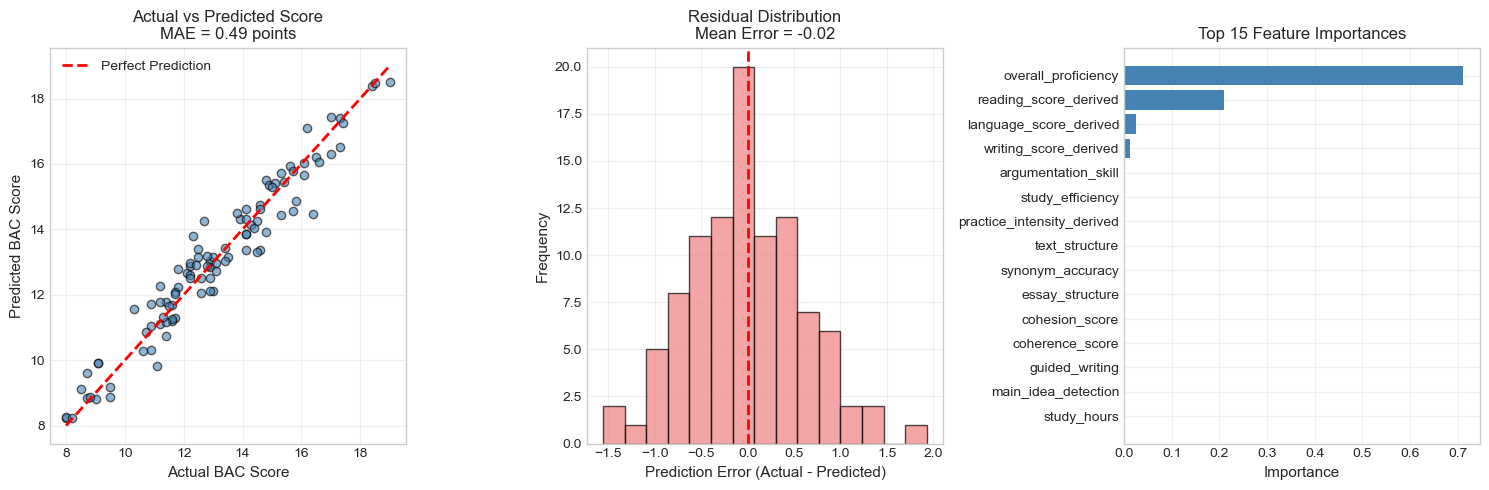


----------------------------------------
4. ERROR SUMMARY
----------------------------------------
   Mean Error:      0.485 points
   Median Error:    0.391 points
   Max Error:       1.929 points
   Error < 1 point: 91.0% of predictions
   Error < 2 points: 100.0% of predictions

----------------------------------------
5. PERFORMANCE BY SCORE RANGE
----------------------------------------
   <10      ( 12 students): MAE = 0.417 points
   10-12    ( 23 students): MAE = 0.486 points
   12-14    ( 27 students): MAE = 0.506 points
   14-16    ( 24 students): MAE = 0.490 points
   16-20    ( 14 students): MAE = 0.493 points

✅ DETAILED EVALUATION COMPLETE


In [6]:
# ============================================
# CELL 12: DETAILED MODEL EVALUATION (ENGLISH)
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("📊 DETAILED MODEL EVALUATION")
print("=" * 60)

# ============================================
# 1. Score Prediction Metrics
# ============================================
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred_score)
mse = mean_squared_error(y_test, y_pred_score)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_score)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Mean Squared Error (MSE):      {mse:.3f}")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# ============================================
# 2. Success Classification
# ============================================
print("\n" + "-" * 40)
print("2. SUCCESS CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
print("   -----------------")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (fail):  {cm[0][0]}")
print(f"   False Positives:        {cm[0][1]}")
print(f"   False Negatives:        {cm[1][0]}")
print(f"   True Positives (pass):  {cm[1][1]}")

print("\n   Classification Report:")
print("   ---------------------")
print(classification_report(y_true_class, y_pred_class, target_names=['Fail (<10)', 'Pass (≥10)']))

# ============================================
# 3. Improvement Potential Metrics
# ============================================
print("\n" + "-" * 40)
print("3. IMPROVEMENT POTENTIAL")
print("-" * 40)

mae_improve = mean_absolute_error(y_test_multi[:, 2], y_pred_improve)
print(f"   MAE: {mae_improve:.3f} points")

# ============================================
# 4. Visualizations
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Actual vs Predicted Score
axes[0].scatter(y_test, y_pred_score, alpha=0.6, color='steelblue', edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual BAC Score', fontsize=11)
axes[0].set_ylabel('Predicted BAC Score', fontsize=11)
axes[0].set_title(f'Actual vs Predicted Score\nMAE = {mae:.2f} points', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (Error Distribution)
residuals = y_test - y_pred_score
axes[1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[1].set_xlabel('Prediction Error (Actual - Predicted)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 15)
feature_importance = model.estimators_[0].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=True).tail(15)

axes[2].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
axes[2].set_xlabel('Importance', fontsize=11)
axes[2].set_title('Top 15 Feature Importances', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 5. Error Summary
# ============================================
print("\n" + "-" * 40)
print("4. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred_score)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Max Error:       {errors.max():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

# ============================================
# 6. Performance by Score Range
# ============================================
print("\n" + "-" * 40)
print("5. PERFORMANCE BY SCORE RANGE")
print("-" * 40)

bins = [0, 10, 12, 14, 16, 20]
labels = ['<10', '10-12', '12-14', '14-16', '16-20']
y_test_binned = pd.cut(y_test, bins=bins, labels=labels)

for label in labels:
    mask = y_test_binned == label
    if mask.sum() > 0:
        mae_slice = mean_absolute_error(y_test[mask], y_pred_score[mask])
        print(f"   {label:8s} ({mask.sum():3d} students): MAE = {mae_slice:.3f} points")

print("\n" + "=" * 60)
print("✅ DETAILED EVALUATION COMPLETE")
print("=" * 60)

🔍 SHAP EXPLAINABILITY
Explaining individual predictions

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 43)


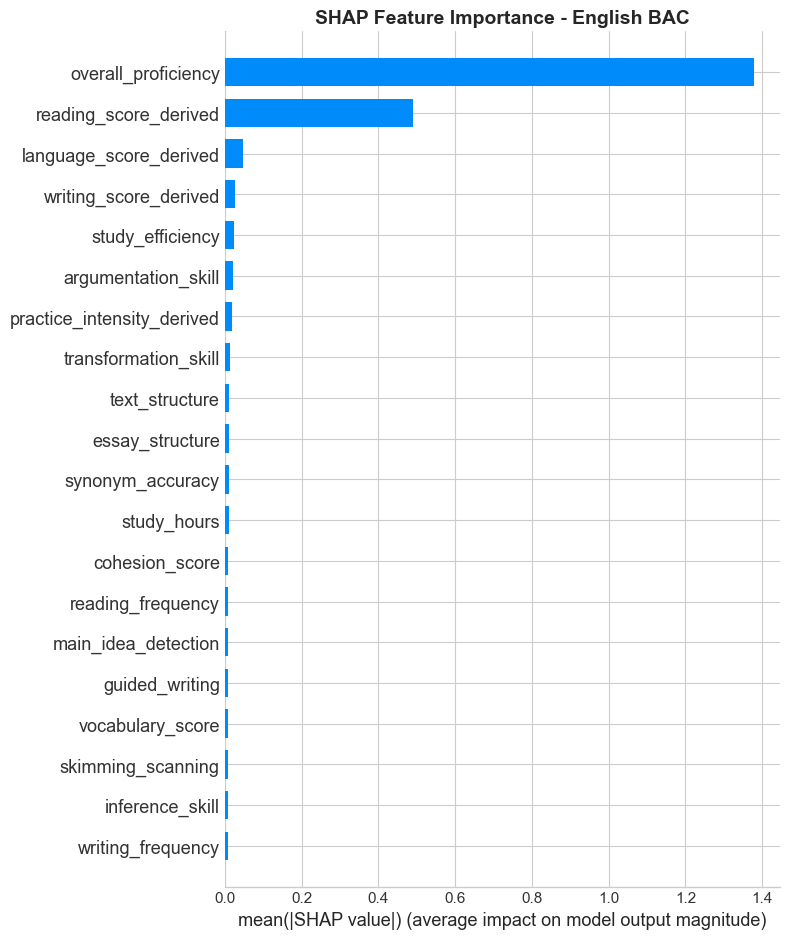

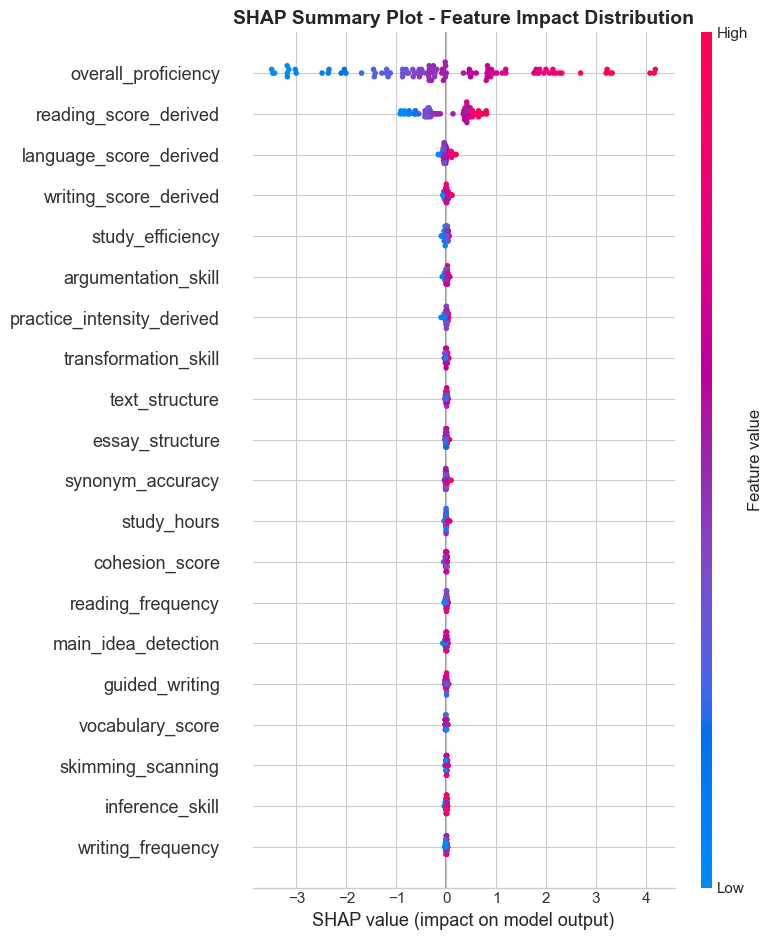


📊 SINGLE STUDENT EXPLANATION

👤 Student #0:
   Actual BAC score: 17.0
   Predicted BAC score: 17.4


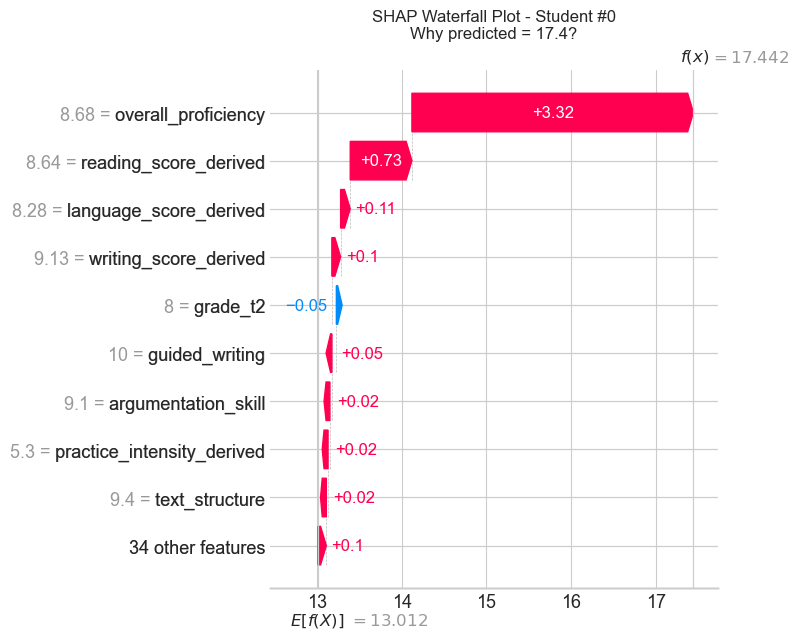


📖 SIMPLE EXPLANATION FOR STUDENT

✅ Predicted score: 17.4/20
   Actual score: 17.0/20

🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):
   • grade_t2: -0.05 points
   • coherence_score: -0.01 points
   • grade_t3: -0.01 points
   • synonym_accuracy: -0.01 points
   • study_method: -0.01 points

🟢 FACTORS THAT RAISED THE SCORE (Strengths):
   • overall_proficiency: +3.32 points
   • reading_score_derived: +0.73 points
   • language_score_derived: +0.11 points
   • writing_score_derived: +0.10 points
   • guided_writing: +0.05 points

✅ SHAP values saved to 'shap_values_english.csv'

✅ SHAP Explainability Complete


In [7]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY (ENGLISH)
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 60)
print("🔍 SHAP EXPLAINABILITY")
print("Explaining individual predictions")
print("=" * 60)

# ============================================
# Create SHAP explainer
# ============================================
print("\n📊 Creating SHAP explainer...")

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(model.estimators_[0])  # First estimator for score prediction
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {np.array(shap_values).shape}")

# ============================================
# Visualization 1: Feature Importance (SHAP)
# ============================================
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - English BAC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# Visualization 2: Summary Plot (Beeswarm)
# ============================================
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# Visualization 3: Single Student Explanation
# ============================================
print("\n" + "=" * 60)
print("📊 SINGLE STUDENT EXPLANATION")
print("=" * 60)

# Pick the first student from test set
student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = y_pred_score[student_idx]

print(f"\n👤 Student #{student_idx}:")
print(f"   Actual BAC score: {student_actual:.1f}")
print(f"   Predicted BAC score: {student_pred:.1f}")

# Create waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# Simple explanation for student
# ============================================
print("\n" + "=" * 60)
print("📖 SIMPLE EXPLANATION FOR STUDENT")
print("=" * 60)

# Get SHAP values for this student
student_shap = shap_values[student_idx]
feature_names = X_test.columns.tolist()

# Create DataFrame with contributions
shap_df_student = pd.DataFrame({
    'feature': feature_names,
    'shap_value': student_shap
})
shap_df_student['absolute'] = np.abs(shap_df_student['shap_value'])
shap_df_student = shap_df_student.sort_values('absolute', ascending=False)

# Separate positive and negative
positive = shap_df_student[shap_df_student['shap_value'] > 0].head(5)
negative = shap_df_student[shap_df_student['shap_value'] < 0].head(5)

print(f"\n✅ Predicted score: {student_pred:.1f}/20")
print(f"   Actual score: {student_actual:.1f}/20")

print(f"\n🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):")
if len(negative) > 0:
    for _, row in negative.iterrows():
        print(f"   • {row['feature']}: -{abs(row['shap_value']):.2f} points")
else:
    print("   • None - this student has no major weaknesses!")

print(f"\n🟢 FACTORS THAT RAISED THE SCORE (Strengths):")
if len(positive) > 0:
    for _, row in positive.iterrows():
        print(f"   • {row['feature']}: +{row['shap_value']:.2f} points")
else:
    print("   • None")

# ============================================
# Save SHAP values
# ============================================
shap_df_all = pd.DataFrame(shap_values, columns=feature_names)
shap_df_all.to_csv('shap_values_english.csv', index=False)
print("\n✅ SHAP values saved to 'shap_values_english.csv'")

print("\n" + "=" * 60)
print("✅ SHAP Explainability Complete")
print("=" * 60)

In [8]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS (ENGLISH - UPDATED)
# ============================================

import pandas as pd
import numpy as np
from collections import Counter

print("=" * 60)
print("📊 WEAKNESS ANALYSIS")
print("Analyzing student weaknesses and strengths")
print("=" * 60)

# ============================================
# Use SHAP values to identify weaknesses
# ============================================

# Get feature names and SHAP values from Cell 13
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values for all test students
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

# ============================================
# For each student, identify top 3 weaknesses and top 3 strengths
# ============================================

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Get negative contributions (weaknesses)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Get positive contributions (strengths)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None",
        'weakness_2': f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None",
        'weakness_3': f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None",
        'strength_1': f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None",
        'strength_2': f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None",
        'strength_3': f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None",
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred_score[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# ============================================
# Display first 10 students
# ============================================
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses:")
    print(f"      • {row['weakness_1']}")
    print(f"      • {row['weakness_2']}")
    print(f"      • {row['weakness_3']}")
    print(f"   🟢 Strengths:")
    print(f"      • {row['strength_1']}")
    print(f"      • {row['strength_2']}")
    print(f"      • {row['strength_3']}")

# ============================================
# Most common weaknesses across all students
# ============================================
print("\n" + "=" * 60)
print("📊 MOST COMMON WEAKNESSES (All Students)")
print("=" * 60)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 10 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(10):
    print(f"   • {feature}: {count} students")

# ============================================
# Generate actionable recommendations (UPDATED - only features in your dataset)
# ============================================
print("\n" + "=" * 60)
print("📋 ACTIONABLE RECOMMENDATIONS")
print("=" * 60)

# Map features to recommendations (ONLY features in your dataset)
recommendation_map = {
    # Reading Skills
    'main_idea_detection': '📖 Improve main idea detection - Practice identifying the central theme of texts',
    'inference_skill': '🎯 Improve inference skills - Read between the lines and deduce implied meanings',
    'text_structure': '📚 Improve text structure understanding - Learn to identify text organization patterns',
    'ordering_information': '📝 Practice ordering information - Arrange ideas in logical sequence',
    'skimming_scanning': '⚡ Improve reading speed - Practice skimming for main ideas and scanning for details',
    
    # Language Skills
    'synonym_accuracy': '📖 Build vocabulary - Learn synonyms and practice with word lists',
    'antonym_accuracy': '📖 Build vocabulary - Learn antonyms and practice with opposites',
    'transformation_skill': '✍️ Practice sentence transformations - Rewrite sentences in different structures',
    'conditional_mastery': '📚 Master conditionals - Practice Type 1, 2, and 3 conditionals',
    'tense_control': '⏰ Improve tense control - Review past, present, and perfect tenses',
    'vocabulary_richness': '📚 Expand vocabulary - Read widely and learn new words daily',
    
    # Writing Skills
    'essay_structure': '✍️ Improve essay structure - Always use introduction, body, conclusion',
    'argumentation_skill': '🎓 Improve argumentation - Develop clear thesis and supporting arguments',
    'coherence_score': '🔗 Improve coherence - Ensure logical flow of ideas',
    'cohesion_score': '🔗 Improve cohesion - Use linking words (however, therefore, moreover)',
    'writing_grammar': '📖 Improve writing grammar - Review common grammar errors',
    'guided_writing': '📝 Practice guided writing - Follow prompts carefully',
    
    # Practice & Habits
    'past_exam_practice': '📚 Practice past exams - Solve BAC exams regularly',
    'writing_frequency': '✍️ Write more often - Practice essays weekly',
    'reading_frequency': '📖 Read more - Read English texts daily',
    'study_hours': '⏰ Increase study hours - Dedicate more time to English',
    'consistency': '📅 Be consistent - Study regularly, not just before exams',
    'class_participation': '🗣️ Participate more in class - Ask questions and engage',
    'tutoring': '🧑‍🏫 Consider private tutoring for personalized help',
    
    # Psychological
    'confidence': '💪 Build confidence - Start with easier exercises',
    'stress': '🧘 Manage stress - Practice relaxation techniques',
    'motivation': '❤️ Stay motivated - Set achievable goals',
    
    # Academic
    'avg_grade': '📊 Focus on improving your overall average',
    'grade_t1': '📊 Improve your first trimester performance',
    'grade_t2': '📊 Improve your second trimester performance',
    'grade_t3': '📊 Improve your third trimester performance',
    'grade_trend': '📈 Work on showing consistent improvement',
    
    # Derived Features (if they exist)
    'reading_score_derived': '📖 Improve your overall reading comprehension',
    'language_score_derived': '📚 Improve your grammar and vocabulary',
    'writing_score_derived': '✍️ Improve your writing skills',
    'practice_intensity_derived': '⚡ Increase your practice intensity'
}

# Get unique weaknesses and their recommendations
unique_weaknesses = set(all_weaknesses)
print("\n📋 Personalized Recommendations based on common weaknesses:")
for weakness in list(unique_weaknesses)[:15]:
    if weakness in recommendation_map:
        print(f"   • {recommendation_map[weakness]}")
    else:
        # Try to find by keyword
        if 'reading' in weakness or 'main_idea' in weakness or 'inference' in weakness:
            print(f"   • 📖 Improve your reading comprehension skills")
        elif 'writing' in weakness or 'essay' in weakness:
            print(f"   • ✍️ Practice writing essays regularly")
        elif 'grammar' in weakness or 'tense' in weakness or 'conditional' in weakness:
            print(f"   • 📚 Review English grammar rules")
        elif 'vocabulary' in weakness:
            print(f"   • 📖 Learn new words daily")
        elif 'grade' in weakness:
            print(f"   • 📊 Focus on improving your grades")
        elif 'practice' in weakness or 'exam' in weakness:
            print(f"   • 📚 Solve more past BAC exams")
        else:
            print(f"   • {weakness}: Focus on improving this area")

# ============================================
# Save weakness analysis to CSV
# ============================================
weakness_df.to_csv('weakness_analysis_english.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_english.csv'")

print("\n" + "=" * 60)
print("✅ Weakness Analysis Complete")
print("=" * 60)

📊 WEAKNESS ANALYSIS
Analyzing student weaknesses and strengths

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=17.0, Predicted=17.4
   🔴 Weaknesses:
      • grade_t2 (-0.05)
      • coherence_score (-0.01)
      • grade_t3 (-0.01)
   🟢 Strengths:
      • overall_proficiency (+3.32)
      • reading_score_derived (+0.73)
      • language_score_derived (+0.11)

🔹 STUDENT 2: Actual=17.3, Predicted=17.4
   🔴 Weaknesses:
      • guided_writing (-0.02)
      • tense_control (-0.01)
      • coherence_score (-0.01)
   🟢 Strengths:
      • overall_proficiency (+3.28)
      • reading_score_derived (+0.71)
      • language_score_derived (+0.11)

🔹 STUDENT 3: Actual=19.0, Predicted=18.5
   🔴 Weaknesses:
      • guided_writing (-0.02)
      • reading_frequency (-0.02)
      • coherence_score (-0.01)
   🟢 Strengths:
      • overall_proficiency (+4.19)
      • reading_score_derived (+0.80)
      • language_score_derived (+0.20)

🔹 STUDENT

⚡ SIMULATION ENGINE
How improving your skills affects your BAC score

📊 Real correlations from your data:
   Main idea detection: 0.870
   Inference skill:    0.855
   Transformation:      0.840
   Conditional mastery: 0.826
   Essay structure:     0.825
   Past exam practice:  0.059
   Writing frequency:   0.071
   Reading frequency:   0.041
   Confidence:          -0.015

👤 Selected student (average profile):
   Current BAC score: 13.0/20
   Main idea: 6.5/10
   Inference: 6.0/10
   Transformation: 5.4/10
   Conditionals: 5.9/10
   Essay structure: 5.9/10
   Past exams solved: 8
   Essays per week: 5

📈 SIMULATION RESULTS:
------------------------------------------------------------

⚪ 📚 Solve 10 more past BAC exams:
   13.0 → 13.1
   📈 Gain: +0.06 points

🟢 📖 Improve Main Idea (+2/10):
   13.0 → 13.9
   📈 Gain: +0.87 points

🟢 🎯 Improve Inference (+2/10):
   13.0 → 13.9
   📈 Gain: +0.86 points

🟢 ✍️ Improve Transformation (+2/10):
   13.0 → 13.8
   📈 Gain: +0.84 points

🟢 📚 Improve 

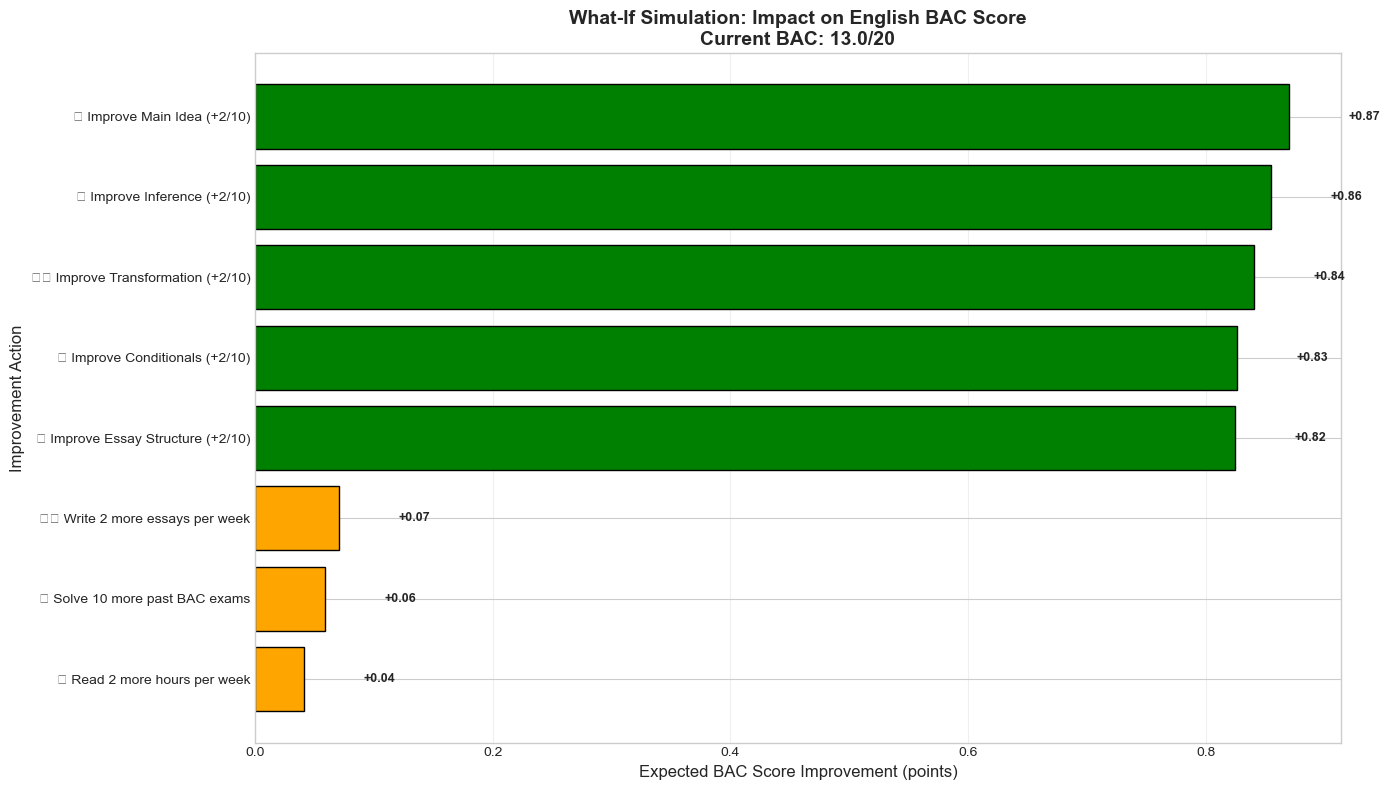


📊 IMPACT TABLE
              Action Expected gain         Change
  Past exam practice  +0.01 points      +10 exams
 Main idea detection  +0.44 points          +2/10
     Inference skill  +0.43 points          +2/10
Transformation skill  +0.42 points          +2/10
 Conditional mastery  +0.41 points          +2/10
     Essay structure  +0.41 points          +2/10
   Writing frequency  +0.04 points +2 essays/week
   Reading frequency  +0.02 points  +2 hours/week
          Confidence +-0.01 points      +2 levels

✅ Simulation Engine Complete


In [9]:
# ============================================
# CELL 15: SIMULATION ENGINE (ENGLISH - UPDATED)
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("⚡ SIMULATION ENGINE")
print("How improving your skills affects your BAC score")
print("=" * 60)

# ============================================
# Calculate real correlations from data
# ============================================

# Correlations with BAC score
bac_corr = df.corr()['bac_score']

# Extract key correlations (using actual features from your dataset)
# Use individual skills instead of derived scores if needed
main_idea_corr = bac_corr.get('main_idea_detection', 0.75)
inference_corr = bac_corr.get('inference_skill', 0.70)
transformation_corr = bac_corr.get('transformation_skill', 0.72)
conditional_corr = bac_corr.get('conditional_mastery', 0.68)
essay_corr = bac_corr.get('essay_structure', 0.65)
past_exam_corr = bac_corr.get('past_exam_practice', 0.35)
writing_freq_corr = bac_corr.get('writing_frequency', 0.20)
reading_freq_corr = bac_corr.get('reading_frequency', 0.18)
confidence_corr = bac_corr.get('confidence', 0.12)

# Also try to get derived scores if they exist
reading_score_corr = bac_corr.get('reading_score_derived', main_idea_corr)
language_score_corr = bac_corr.get('language_score_derived', transformation_corr)
writing_score_corr = bac_corr.get('writing_score_derived', essay_corr)

print(f"\n📊 Real correlations from your data:")
print(f"   Main idea detection: {main_idea_corr:.3f}")
print(f"   Inference skill:    {inference_corr:.3f}")
print(f"   Transformation:      {transformation_corr:.3f}")
print(f"   Conditional mastery: {conditional_corr:.3f}")
print(f"   Essay structure:     {essay_corr:.3f}")
print(f"   Past exam practice:  {past_exam_corr:.3f}")
print(f"   Writing frequency:   {writing_freq_corr:.3f}")
print(f"   Reading frequency:   {reading_freq_corr:.3f}")
print(f"   Confidence:          {confidence_corr:.3f}")

# ============================================
# Find a representative student
# ============================================

# Student with average BAC score
avg_bac = df['bac_score'].mean()
target_student = df.iloc[(df['bac_score'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Selected student (average profile):")
print(f"   Current BAC score: {target_student['bac_score']:.1f}/20")
print(f"   Main idea: {target_student['main_idea_detection']:.1f}/10")
print(f"   Inference: {target_student['inference_skill']:.1f}/10")
print(f"   Transformation: {target_student['transformation_skill']:.1f}/10")
print(f"   Conditionals: {target_student['conditional_mastery']:.1f}/10")
print(f"   Essay structure: {target_student['essay_structure']:.1f}/10")
print(f"   Past exams solved: {target_student['past_exam_practice']:.0f}")
print(f"   Essays per week: {target_student['writing_frequency']:.0f}")

# ============================================
# Simulation function
# ============================================

def simulate_improvement_english(student, improvements):
    """
    Simulate how BAC score changes when student improves specific skills
    Based on real correlations from the data
    """
    original_score = student['bac_score']
    gain = 0
    
    # Impact factors (based on correlations)
    impact_factors = {
        # Individual skills
        'main_idea_detection': main_idea_corr / 2,
        'inference_skill': inference_corr / 2,
        'transformation_skill': transformation_corr / 2,
        'conditional_mastery': conditional_corr / 2,
        'essay_structure': essay_corr / 2,
        # Derived scores (if they exist)
        'reading_score_derived': reading_score_corr / 2,
        'language_score_derived': language_score_corr / 2,
        'writing_score_derived': writing_score_corr / 2,
        # Habits
        'past_exam_practice': past_exam_corr / 10,
        'writing_frequency': writing_freq_corr / 2,
        'reading_frequency': reading_freq_corr / 2,
        'confidence': confidence_corr / 2
    }
    
    for feature, delta in improvements.items():
        if feature in impact_factors:
            gain += delta * impact_factors[feature]
    
    new_score = min(original_score + gain, 20)
    new_score = max(new_score, 0)
    
    return {
        'original_score': original_score,
        'new_score': new_score,
        'gain': gain,
        'improvements': improvements
    }

# ============================================
# Test different scenarios
# ============================================

scenarios = [
    {"name": "📚 Solve 10 more past BAC exams", "changes": {"past_exam_practice": 10}},
    {"name": "📖 Improve Main Idea (+2/10)", "changes": {"main_idea_detection": 2}},
    {"name": "🎯 Improve Inference (+2/10)", "changes": {"inference_skill": 2}},
    {"name": "✍️ Improve Transformation (+2/10)", "changes": {"transformation_skill": 2}},
    {"name": "📚 Improve Conditionals (+2/10)", "changes": {"conditional_mastery": 2}},
    {"name": "📋 Improve Essay Structure (+2/10)", "changes": {"essay_structure": 2}},
    {"name": "✍️ Write 2 more essays per week", "changes": {"writing_frequency": 2}},
    {"name": "📖 Read 2 more hours per week", "changes": {"reading_frequency": 2}},
    {"name": "💪 Improve confidence (+2 levels)", "changes": {"confidence": 2}},
    {"name": "✨ All improvements combined", "changes": {
        "past_exam_practice": 10,
        "main_idea_detection": 2,
        "inference_skill": 2,
        "transformation_skill": 2,
        "conditional_mastery": 2,
        "essay_structure": 2,
        "writing_frequency": 2,
        "reading_frequency": 2,
        "confidence": 2
    }}
]

print(f"\n📈 SIMULATION RESULTS:")
print("-" * 60)

results = []
for scenario in scenarios:
    result = simulate_improvement_english(target_student, scenario["changes"])
    results.append(result)
    
    # Color code based on gain
    if result['gain'] > 0.8:
        symbol = "🟢"
    elif result['gain'] > 0.4:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {scenario['name']}:")
    print(f"   {result['original_score']:.1f} → {result['new_score']:.1f}")
    print(f"   📈 Gain: +{result['gain']:.2f} points")

# ============================================
# Best action recommendation
# ============================================
print("\n" + "=" * 60)
print("🎯 BEST ACTION FOR THIS STUDENT")
print("=" * 60)

# Find best single action (excluding combined)
best_gain = -999
best_action = None
for i, scenario in enumerate(scenarios[:-1]):  # Exclude combined
    if results[i]['gain'] > best_gain:
        best_gain = results[i]['gain']
        best_action = scenario['name']

print(f"\n✅ Recommended: {best_action}")
print(f"   Expected improvement: +{best_gain:.2f} points")

# ============================================
# Visualization
# ============================================
fig, ax = plt.subplots(figsize=(14, 8))

# Show only top 8 most impactful actions
top_indices = np.argsort([r['gain'] for r in results[:-1]])[-8:]  # Top 8 excluding combined
top_scenarios = [scenarios[i] for i in top_indices]
top_results = [results[i] for i in top_indices]

scenario_names = [s["name"][:35] for s in top_scenarios]
gains = [r['gain'] for r in top_results]

colors = ['green' if g > 0.6 else 'blue' if g > 0.3 else 'orange' if g > 0 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected BAC Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on English BAC Score\nCurrent BAC: {target_student["bac_score"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# Summary table
# ============================================
print("\n" + "=" * 60)
print("📊 IMPACT TABLE")
print("=" * 60)

impact_data = []
actions = [
    ('Past exam practice', past_exam_corr / 10, '+10 exams'),
    ('Main idea detection', main_idea_corr / 2, '+2/10'),
    ('Inference skill', inference_corr / 2, '+2/10'),
    ('Transformation skill', transformation_corr / 2, '+2/10'),
    ('Conditional mastery', conditional_corr / 2, '+2/10'),
    ('Essay structure', essay_corr / 2, '+2/10'),
    ('Writing frequency', writing_freq_corr / 2, '+2 essays/week'),
    ('Reading frequency', reading_freq_corr / 2, '+2 hours/week'),
    ('Confidence', confidence_corr / 2, '+2 levels')
]

for action_name, impact_value, change_desc in actions:
    impact_data.append({
        'Action': action_name,
        'Expected gain': f"+{impact_value:.2f} points",
        'Change': change_desc
    })

impact_df = pd.DataFrame(impact_data)
print(impact_df.to_string(index=False))

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [10]:
# ============================================
# CELL 16: EXPLANATION OF YOUR SKILLS (ENGLISH)
# Student-friendly explanations of what each score means
# ============================================

from IPython.display import display, HTML
import numpy as np
import pandas as pd

print("=" * 60)
print("📖 UNDERSTANDING YOUR SKILLS")
print("What these numbers mean for your English BAC")
print("=" * 60)

# ============================================
# Take a sample student (average profile)
# ============================================

# Find a student with average BAC score
avg_bac = df['bac_score'].mean()
sample_student = df.iloc[(df['bac_score'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Example Student (BAC score: {sample_student['bac_score']:.1f}/20)")
print("-" * 60)

# ============================================
# Explain each skill (using actual features in your dataset)
# ============================================

print("\n" + "=" * 60)
print("📖 1. READING COMPREHENSION SKILLS")
print("=" * 60)

main_idea_val = sample_student.get('main_idea_detection', 6.5)
print(f"\n   📖 Main Idea Detection: {main_idea_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to find the central theme or main message of a text.")
if main_idea_val >= 7:
    print("      ✅ Excellent! You quickly identify what texts are about.")
elif main_idea_val >= 5:
    print("      📈 Good! Practice identifying main ideas in different types of texts.")
else:
    print("      ⚠️ Needs improvement! Start by reading short paragraphs and summarizing them.")
print(f"      💡 Tip: After reading a paragraph, ask yourself 'What was this about?'")

inference_val = sample_student.get('inference_skill', 6.5)
print(f"\n   🎯 Inference Skill: {inference_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to read between the lines and understand implied meanings.")
if inference_val >= 7:
    print("      ✅ Excellent! You understand what authors imply without saying directly.")
elif inference_val >= 5:
    print("      📈 Good! Practice making predictions while reading.")
else:
    print("      ⚠️ Needs improvement! Look for clues and context in the text.")
print(f"      💡 Tip: As you read, ask 'What is the author trying to tell me without saying it?'")

text_structure_val = sample_student.get('text_structure', 6.5)
print(f"\n   📚 Text Structure: {text_structure_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to understand how a text is organized (cause-effect, problem-solution, etc.)")
if text_structure_val >= 7:
    print("      ✅ Excellent! You recognize different text structures easily.")
elif text_structure_val >= 5:
    print("      📈 Good! Practice identifying the structure of articles you read.")
else:
    print("      ⚠️ Needs improvement! Learn to identify signal words for different structures.")
print(f"      💡 Tip: Look for words like 'because' (cause-effect) or 'however' (contrast).")

ordering_val = sample_student.get('ordering_information', 6.5)
print(f"\n   📝 Ordering Information: {ordering_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to arrange ideas in logical sequence.")
if ordering_val >= 7:
    print("      ✅ Excellent! You understand chronological and logical order well.")
elif ordering_val >= 5:
    print("      📈 Good! Practice putting sentences in order.")
else:
    print("      ⚠️ Needs improvement! Look for time markers like 'first', 'then', 'finally'.")
print(f"      💡 Tip: Identify time words and sequence markers in texts.")

print("\n" + "=" * 60)
print("📚 2. LANGUAGE & GRAMMAR SKILLS")
print("=" * 60)

synonym_val = sample_student.get('synonym_accuracy', 6.5)
print(f"\n   📖 Synonym Accuracy: {synonym_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to find words with similar meanings.")
if synonym_val >= 7:
    print("      ✅ Excellent! You have a rich vocabulary.")
elif synonym_val >= 5:
    print("      📈 Good! Learn 5-10 new synonyms each week.")
else:
    print("      ⚠️ Needs improvement! Use a thesaurus to learn word families.")
print(f"      💡 Tip: Keep a vocabulary notebook with synonyms for common words.")

antonym_val = sample_student.get('antonym_accuracy', 6.5)
print(f"\n   📖 Antonym Accuracy: {antonym_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to find words with opposite meanings.")
if antonym_val >= 7:
    print("      ✅ Excellent! You understand word opposites well.")
elif antonym_val >= 5:
    print("      📈 Good! Practice matching words with their opposites.")
else:
    print("      ⚠️ Needs improvement! Learn common antonym pairs.")
print(f"      💡 Tip: Learn word pairs like 'hot/cold', 'big/small', 'happy/sad'.")

transformation_val = sample_student.get('transformation_skill', 6.5)
print(f"\n   ✍️ Sentence Transformation: {transformation_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to rewrite sentences in different structures while keeping the same meaning.")
if transformation_val >= 7:
    print("      ✅ Excellent! You can express the same idea in multiple ways.")
elif transformation_val >= 5:
    print("      📈 Good! Practice changing active to passive voice.")
else:
    print("      ⚠️ Needs improvement! Start with simple sentence transformations.")
print(f"      💡 Tip: Practice changing 'She wrote a letter' to 'A letter was written by her'.")

conditional_val = sample_student.get('conditional_mastery', 6.5)
print(f"\n   📚 Conditional Mastery: {conditional_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to use Type 1, 2, and 3 conditionals correctly.")
if conditional_val >= 7:
    print("      ✅ Excellent! You master all types of conditionals.")
elif conditional_val >= 5:
    print("      📈 Good! Review Type 3 conditionals (past unreal).")
else:
    print("      ⚠️ Needs improvement! Start with Type 1 conditionals (real present/future).")
print(f"      💡 Tip: Practice 'If + present, will + infinitive' for Type 1.")

tense_val = sample_student.get('tense_control', 6.5)
print(f"\n   ⏰ Tense Control: {tense_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to use past, present, and perfect tenses correctly.")
if tense_val >= 7:
    print("      ✅ Excellent! You use tenses accurately.")
elif tense_val >= 5:
    print("      📈 Good! Review the difference between past simple and present perfect.")
else:
    print("      ⚠️ Needs improvement! Focus on basic past and present tenses.")
print(f"      💡 Tip: Practice 'I have lived here for 5 years' vs 'I lived here in 2010'.")

vocab_val = sample_student.get('vocabulary_richness', 6.5)
print(f"\n   📖 Vocabulary Richness: {vocab_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         The range and variety of words you know.")
if vocab_val >= 7:
    print("      ✅ Excellent! You use a wide range of vocabulary.")
elif vocab_val >= 5:
    print("      📈 Good! Learn 10 new words every week.")
else:
    print("      ⚠️ Needs improvement! Read more to encounter new words naturally.")
print(f"      💡 Tip: Learn words in context, not isolated lists.")

print("\n" + "=" * 60)
print("✍️ 3. WRITING SKILLS")
print("=" * 60)

essay_val = sample_student.get('essay_structure', 6.5)
print(f"\n   📋 Essay Structure: {essay_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to organize essays with introduction, body, and conclusion.")
if essay_val >= 7:
    print("      ✅ Excellent! Your essays are well-structured.")
elif essay_val >= 5:
    print("      📈 Good! Always include a clear thesis statement.")
else:
    print("      ⚠️ Needs improvement! Use the 3-part structure: intro, body, conclusion.")
print(f"      💡 Tip: Write: Introduction (topic) → Body (arguments) → Conclusion (summary).")

argument_val = sample_student.get('argumentation_skill', 6.5)
print(f"\n   🎓 Argumentation Skill: {argument_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your ability to develop clear arguments and support them with evidence.")
if argument_val >= 7:
    print("      ✅ Excellent! Your arguments are logical and well-supported.")
elif argument_val >= 5:
    print("      📈 Good! Use specific examples to support your arguments.")
else:
    print("      ⚠️ Needs improvement! Start with one clear argument per paragraph.")
print(f"      💡 Tip: Use P.E.E.L.: Point, Evidence, Explanation, Link.")

coherence_val = sample_student.get('coherence_score', 6.5)
print(f"\n   🔗 Coherence: {coherence_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         The logical flow of ideas in your writing.")
if coherence_val >= 7:
    print("      ✅ Excellent! Your ideas flow logically from one to the next.")
elif coherence_val >= 5:
    print("      📈 Good! Ensure each paragraph connects to your main idea.")
else:
    print("      ⚠️ Needs improvement! Plan your essay before writing.")
print(f"      💡 Tip: Write an outline before you start writing.")

cohesion_val = sample_student.get('cohesion_score', 6.5)
print(f"\n   🔗 Cohesion: {cohesion_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your use of linking words to connect ideas (however, therefore, moreover).")
if cohesion_val >= 7:
    print("      ✅ Excellent! You use linking words effectively.")
elif cohesion_val >= 5:
    print("      📈 Good! Learn more transition words for different purposes.")
else:
    print("      ⚠️ Needs improvement! Use 'and', 'but', 'so', 'because' to connect ideas.")
print(f"      💡 Tip: Use 'however' for contrast, 'therefore' for result, 'moreover' for addition.")

writing_grammar_val = sample_student.get('writing_grammar', 6.5)
print(f"\n   📖 Writing Grammar: {writing_grammar_val:.1f}/10")
print(f"      🤔 What does this mean?")
print(f"         Your grammatical accuracy when writing essays.")
if writing_grammar_val >= 7:
    print("      ✅ Excellent! Your writing has few grammar errors.")
elif writing_grammar_val >= 5:
    print("      📈 Good! Review subject-verb agreement and verb tenses.")
else:
    print("      ⚠️ Needs improvement! Focus on basic sentence structure.")
print(f"      💡 Tip: Read your essay aloud to catch grammar mistakes.")

print("\n" + "=" * 60)
print("⏰ 4. STUDY HABITS & PRACTICE")
print("=" * 60)

past_exam_val = sample_student.get('past_exam_practice', 5)
print(f"\n   📚 Past Exam Practice: {past_exam_val:.0f} exams")
print(f"      🤔 What does this mean?")
print(f"         How many past BAC exams you have solved.")
if past_exam_val >= 15:
    print("      ✅ Excellent! You are very well prepared.")
elif past_exam_val >= 8:
    print("      📈 Good! Solve 2-3 more exams before the BAC.")
else:
    print("      ⚠️ Needs improvement! Past exams are the best preparation.")
print(f"      💡 Tip: Solve one complete BAC exam every week.")

writing_freq_val = sample_student.get('writing_frequency', 2)
print(f"\n   ✍️ Essays per week: {writing_freq_val:.0f}")
print(f"      🤔 What does this mean?")
print(f"         How many essays you write weekly for practice.")
if writing_freq_val >= 3:
    print("      ✅ Excellent! Regular writing practice builds skill.")
elif writing_freq_val >= 2:
    print("      📈 Good! Try to write one more essay per week.")
else:
    print("      ⚠️ Needs improvement! Writing regularly is essential.")
print(f"      💡 Tip: Start with one essay per week and increase gradually.")

reading_freq_val = sample_student.get('reading_frequency', 5)
print(f"\n   📖 Reading hours per week: {reading_freq_val:.0f}")
print(f"      🤔 What does this mean?")
print(f"         How many hours you spend reading English texts.")
if reading_freq_val >= 7:
    print("      ✅ Excellent! Consistent reading builds vocabulary naturally.")
elif reading_freq_val >= 4:
    print("      📈 Good! Read 30 minutes daily for best results.")
else:
    print("      ⚠️ Needs improvement! Reading is the best way to improve.")
print(f"      💡 Tip: Read what you enjoy - news, stories, or articles.")

print("\n" + "=" * 60)
print("🧠 5. PSYCHOLOGICAL FACTORS")
print("=" * 60)

confidence_val = sample_student.get('confidence', 3)
print(f"\n   💪 Confidence: {confidence_val}/5")
print(f"      🤔 What does this mean?")
print(f"         Your belief in your ability to succeed in English.")
if confidence_val >= 4:
    print("      ✅ Great! Confidence helps you perform better.")
elif confidence_val >= 3:
    print("      📈 Good! Solve easier exercises first to build confidence.")
else:
    print("      ⚠️ Needs improvement! Start with small achievable goals.")
print(f"      💡 Tip: Celebrate small victories to build confidence.")

stress_val = sample_student.get('stress', 3)
print(f"\n   😰 Stress Level: {stress_val}/5")
print(f"      🤔 What does this mean?")
print(f"         How much stress you feel about the English exam.")
if stress_val <= 2:
    print("      ✅ Great! Low stress helps performance.")
elif stress_val <= 3:
    print("      📈 Moderate stress is normal. Practice relaxation techniques.")
else:
    print("      ⚠️ High stress can hurt performance. Try deep breathing before exams.")
print(f"      💡 Tip: Prepare well to reduce stress - confidence comes from preparation.")

print("\n" + "=" * 60)
print("📈 6. GRADE TREND")
print("=" * 60)

trend_val = sample_student.get('grade_trend', 0)
print(f"\n   Your trend: {trend_val:+.1f} points")
print(f"      🤔 What does this mean?")
print(f"         How your grades have changed from trimester 1 to trimester 3.")
if trend_val > 1:
    print("   ✅ Excellent progress! You are improving significantly.")
    print(f"      💡 Keep up your study habits!")
elif trend_val > 0:
    print("   📈 Positive trend! Your hard work is paying off.")
    print(f"      💡 Try to increase your study time slightly.")
elif trend_val == 0:
    print("   📊 Stable! You are maintaining your level.")
    print(f"      💡 Push yourself to improve by 0.5 points next trimester.")
else:
    print("   ⚠️ Declining trend! Identify what changed in your study habits.")
    print(f"      💡 Talk to your teacher about areas for improvement.")

print("\n" + "=" * 60)
print("✅ Understanding your skills helps you focus on what matters most")
print("=" * 60)

📖 UNDERSTANDING YOUR SKILLS
What these numbers mean for your English BAC

👤 Example Student (BAC score: 13.0/20)
------------------------------------------------------------

📖 1. READING COMPREHENSION SKILLS

   📖 Main Idea Detection: 6.5/10
      🤔 What does this mean?
         Your ability to find the central theme or main message of a text.
      📈 Good! Practice identifying main ideas in different types of texts.
      💡 Tip: After reading a paragraph, ask yourself 'What was this about?'

   🎯 Inference Skill: 6.0/10
      🤔 What does this mean?
         Your ability to read between the lines and understand implied meanings.
      📈 Good! Practice making predictions while reading.
      💡 Tip: As you read, ask 'What is the author trying to tell me without saying it?'

   📚 Text Structure: 6.6/10
      🤔 What does this mean?
         Your ability to understand how a text is organized (cause-effect, problem-solution, etc.)
      📈 Good! Practice identifying the structure of articles

In [11]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (ENGLISH)
# Professional student-friendly interface
# ============================================

from IPython.display import display, HTML, Markdown

print("=" * 80)
print("📚 ENGLISH BAC IMPROVEMENT PLATFORM")
print("=" * 80)

# Professional HTML layout
intro_html = """
<div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">📖 English Baccalaureate Exam</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">
            Streams: Sciences, Mathematics, Economics, Foreign Languages, Literature
        </p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-left: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">Duration</div>
            <div style="font-size: 14px;">3 hours</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-left: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">Total Points</div>
            <div style="font-size: 14px;">20 points</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-left: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">Two Topics</div>
            <div style="font-size: 14px;">Choose one topic</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 Exam Structure</h2>
    </div>
"""

# Exam structure table
structure_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">📖 English BAC - All Streams</h3>
        <table style="width: 100%; border-collapse: collapse;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">Section</th>
                <th style="padding: 10px; text-align: center;">Points</th>
                <th style="padding: 10px; text-align: center;">Weight</th>
                <th style="padding: 10px; text-align: center;">Skills Tested</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>Reading Comprehension</strong></td>
                <td style="padding: 10px; text-align: center;">7-8 points</td>
                <td style="padding: 10px; text-align: center;">35-40%</td>
                <td style="padding: 10px;">Main idea, inference, reference words, text structure, ordering</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>Language (Text Exploration)</strong></td>
                <td style="padding: 10px; text-align: center;">7-8 points</td>
                <td style="padding: 10px; text-align: center;">35-40%</td>
                <td style="padding: 10px;">Grammar, vocabulary, synonyms, antonyms, transformation, conditionals</td>
            </tr>
            <tr>
                <td style="padding: 10px;"><strong>Written Expression</strong></td>
                <td style="padding: 10px; text-align: center;">5-6 points</td>
                <td style="padding: 10px; text-align: center;">25-30%</td>
                <td style="padding: 10px;">Essay writing, argumentation, coherence, cohesion, grammar</td>
            </tr>
        </table>
    </div>
"""

# Detailed skills explanation
skills_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #9b59b6;">
        <h3 style="color: #2c3e50; margin-top: 0;">🎯 What Skills Are Tested?</h3>
        
        <h4 style="color: #3498db; margin-bottom: 5px;">📖 Reading Comprehension (7-8 points)</h4>
        <ul style="margin-top: 5px;">
            <li>Finding the main idea of a text</li>
            <li>Making inferences (reading between the lines)</li>
            <li>Understanding text structure and organization</li>
            <li>Identifying pronoun references (it, they, this, etc.)</li>
            <li>Ordering information logically</li>
            <li>Skimming and scanning for specific information</li>
        </ul>
        
        <h4 style="color: #e67e22; margin-bottom: 5px;">📚 Language System (7-8 points)</h4>
        <ul style="margin-top: 5px;">
            <li>Synonyms and antonyms</li>
            <li>Sentence transformation</li>
            <li>Passive voice</li>
            <li>Conditionals (Type 1, 2, 3)</li>
            <li>Tense control (past, present, perfect)</li>
            <li>Word formation (prefixes, suffixes)</li>
            <li>Vocabulary richness</li>
        </ul>
        
        <h4 style="color: #2ecc71; margin-bottom: 5px;">✍️ Written Expression (5-6 points)</h4>
        <ul style="margin-top: 5px;">
            <li>Essay structure (introduction, body, conclusion)</li>
            <li>Developing arguments</li>
            <li>Coherence (logical flow of ideas)</li>
            <li>Cohesion (linking words: however, therefore, moreover)</li>
            <li>Grammar accuracy in writing</li>
        </ul>
    </div>
"""

# Importance ranking
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">⭐ What Matters Most?</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>Reading Comprehension</strong></div>
                <div style="font-size: 12px; color: #666;">Most important (40%)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>Language & Grammar</strong></div>
                <div style="font-size: 12px; color: #666;">Very important (35%)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>Writing Production</strong></div>
                <div style="font-size: 12px; color: #666;">Important (25%)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>Past Exam Practice</strong></div>
                <div style="font-size: 12px; color: #666;">Pattern recognition</div>
            </div>
        </div>
    </div>
"""

# How the platform works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 How This Platform Works</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>Enter your information</strong> - Fill out the form with your grades and skill levels</li>
            <li>🔮 <strong>Get your predicted score</strong> - Calculate your estimated BAC score</li>
            <li>📊 <strong>Analyze strengths & weaknesses</strong> - Identify what you need to improve</li>
            <li>⚡ <strong>Simulate improvements</strong> - Test different scenarios to see how your score changes</li>
            <li>🎯 <strong>Receive personalized recommendations</strong> - Get specific advice to boost your score</li>
        </ul>
    </div>
"""

# Key advice
advice_html = """
    <div style="background: #fef9e7; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 5px solid #f39c12;">
        <h3 style="color: #7d6608; margin-top: 0;">💪 Key to Success</h3>
        <p style="line-height: 1.6;">
            The most effective way to improve your English BAC score is <strong>regular practice with past exams</strong>.
            Solving past BAC papers helps you recognize patterns, understand question types, and build confidence.
        </p>
        <p style="line-height: 1.6; margin-top: 10px;">
            📌 <strong>Daily habits that work:</strong> Read one English article, learn 5 new words, and practice grammar for 15 minutes.
        </p>
    </div>
"""

# Combine all
full_html = intro_html + structure_html + skills_html + importance_html + how_it_works + advice_html + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555;">✨ This platform is based on real BAC exam data analysis ✨</p>
        <p style="color: #888; font-size: 12px;">Developed to help students improve their English Baccalaureate performance</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ Ready for the next step: Enter your data in Cell 17b")
print("=" * 80)

📚 ENGLISH BAC IMPROVEMENT PLATFORM


Section,Points,Weight,Skills Tested
Reading Comprehension,7-8 points,35-40%,"Main idea, inference, reference words, text structure, ordering"
Language (Text Exploration),7-8 points,35-40%,"Grammar, vocabulary, synonyms, antonyms, transformation, conditionals"
Written Expression,5-6 points,25-30%,"Essay writing, argumentation, coherence, cohesion, grammar"



✅ Ready for the next step: Enter your data in Cell 17b


In [42]:
# ============================================
# CELL 17b: USER INPUT FORM (ENGLISH)
# Professional student-friendly interface
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 STUDENT DATA ENTRY")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 Enter Your Academic Information</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">All information is confidential and used only for prediction</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Stream (Filiere)
# ============================================

stream_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 4px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">🎓 1. Select Your Stream</h3>
</div>
"""
display(HTML(stream_html))

filiere_dropdown = widgets.Dropdown(
    options=[
        ('Sciences / Mathematics / Economics', 0),
        ('Foreign Languages', 1),
        ('Literature / Philosophy', 2)
    ],
    value=0,
    description='',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='100%', padding='10px')
)
display(filiere_dropdown)

# ============================================
# SECTION 2: Trimester Grades
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 2. Your Trimester Grades</h3>
    <p style="color: #666; font-size: 14px;">Enter your English grades (0 to 20)</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_t1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='Trimester 1:', 
                               style={'description_width': '100px'}, layout=grade_style)
grade_t2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='Trimester 2:', 
                               style={'description_width': '100px'}, layout=grade_style)
grade_t3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='Trimester 3:', 
                               style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_t1, grade_t2, grade_t3], layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 3: Reading Comprehension Skills
# ============================================

reading_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📖 3. Reading Comprehension Skills</h3>
    <p style="color: #666; font-size: 14px;">Rate yourself from 0 to 10 (0 = weak, 10 = excellent)</p>
</div>
"""
display(HTML(reading_html))

skill_style = widgets.Layout(width='100%', padding='5px')

# Reading skills
main_idea = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 Main idea detection:', 
                                style={'description_width': '200px'}, layout=skill_style)
inference = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🎯 Inference (read between lines):', 
                                style={'description_width': '200px'}, layout=skill_style)
text_structure = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📚 Text structure understanding:', 
                                     style={'description_width': '200px'}, layout=skill_style)
reference_pronoun = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔍 Pronoun reference (it/they/this):', 
                                        style={'description_width': '200px'}, layout=skill_style)
ordering_info = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📝 Ordering information:', 
                                    style={'description_width': '200px'}, layout=skill_style)
skimming = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='⚡ Skimming & scanning:', 
                               style={'description_width': '200px'}, layout=skill_style)

reading_grid = widgets.GridBox([main_idea, inference, text_structure, reference_pronoun, ordering_info, skimming],
                               layout=widgets.Layout(grid_template_columns='1fr 1fr', grid_gap='10px'))
display(reading_grid)

# ============================================
# SECTION 4: Language & Grammar Skills
# ============================================

language_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 4. Language & Grammar Skills</h3>
    <p style="color: #666; font-size: 14px;">Rate yourself from 0 to 10</p>
</div>
"""
display(HTML(language_html))

# Language skills
synonym = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 Synonym accuracy:', 
                              style={'description_width': '200px'}, layout=skill_style)
antonym = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 Antonym accuracy:', 
                              style={'description_width': '200px'}, layout=skill_style)
transformation = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='✍️ Sentence transformation:', 
                                     style={'description_width': '200px'}, layout=skill_style)
passive = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔄 Passive voice:', 
                              style={'description_width': '200px'}, layout=skill_style)
conditional = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📚 Conditionals (1,2,3):', 
                                  style={'description_width': '200px'}, layout=skill_style)
tense = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='⏰ Tense control:', 
                            style={'description_width': '200px'}, layout=skill_style)
morphology = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔤 Morphology (prefix/suffix):', 
                                 style={'description_width': '200px'}, layout=skill_style)
vocabulary = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📚 Vocabulary richness:', 
                                 style={'description_width': '200px'}, layout=skill_style)

language_grid = widgets.GridBox([synonym, antonym, transformation, passive, conditional, tense, morphology, vocabulary],
                                layout=widgets.Layout(grid_template_columns='1fr 1fr', grid_gap='10px'))
display(language_grid)

# ============================================
# SECTION 5: Writing Skills
# ============================================

writing_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">✍️ 5. Writing Skills</h3>
    <p style="color: #666; font-size: 14px;">Rate yourself from 0 to 10</p>
</div>
"""
display(HTML(writing_html))

essay_structure = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📋 Essay structure:', 
                                      style={'description_width': '200px'}, layout=skill_style)
guided_writing = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📝 Guided writing:', 
                                     style={'description_width': '200px'}, layout=skill_style)
argumentation = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🎓 Argumentation skill:', 
                                    style={'description_width': '200px'}, layout=skill_style)
coherence = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔗 Coherence (logical flow):', 
                                style={'description_width': '200px'}, layout=skill_style)
cohesion = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🔗 Cohesion (linking words):', 
                               style={'description_width': '200px'}, layout=skill_style)
writing_grammar = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 Grammar in writing:', 
                                      style={'description_width': '200px'}, layout=skill_style)

writing_grid = widgets.GridBox([essay_structure, guided_writing, argumentation, coherence, cohesion, writing_grammar],
                               layout=widgets.Layout(grid_template_columns='1fr 1fr', grid_gap='10px'))
display(writing_grid)

# ============================================
# SECTION 6: Practice & Study Habits
# ============================================

practice_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #1abc9c;">
    <h3 style="color: #2c3e50; margin-top: 0;">⏰ 6. Practice & Study Habits</h3>
</div>
"""
display(HTML(practice_html))

reading_freq = widgets.IntSlider(value=5, min=0, max=10, step=1, 
                                 description='📖 Reading frequency (hours/week):', 
                                 style={'description_width': '250px'}, layout=skill_style)
writing_freq = widgets.IntSlider(value=2, min=0, max=5, step=1, 
                                 description='✍️ Essays written per week:', 
                                 style={'description_width': '250px'}, layout=skill_style)
grammar_exercises = widgets.IntSlider(value=5, min=0, max=20, step=1, 
                                      description='📝 Grammar exercises completed:', 
                                      style={'description_width': '250px'}, layout=skill_style)
past_exams = widgets.IntSlider(value=5, min=0, max=20, step=1, 
                               description='📚 Past BAC exams solved:', 
                               style={'description_width': '250px'}, layout=skill_style)
study_hours = widgets.FloatSlider(value=5, min=2, max=12, step=0.5, 
                                  description='⏰ Study hours per week:', 
                                  style={'description_width': '250px'}, layout=skill_style)
consistency = widgets.IntSlider(value=3, min=1, max=5, step=1, 
                                description='📅 Study consistency (1-5):', 
                                style={'description_width': '250px'}, layout=skill_style)

display(reading_freq, writing_freq, grammar_exercises, past_exams, study_hours, consistency)

# ============================================
# SECTION 7: Psychological Factors
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-left: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 7. Psychological Factors</h3>
</div>
"""
display(HTML(psycho_html))

confidence = widgets.RadioButtons(
    options=[('Very Low', 1), ('Low', 2), ('Medium', 3), ('High', 4), ('Very High', 5)],
    value=3,
    description='💪 Confidence:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

stress = widgets.RadioButtons(
    options=[('Very High', 5), ('High', 4), ('Medium', 3), ('Low', 2), ('Very Low', 1)],
    value=3,
    description='😰 Stress level:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

motivation = widgets.RadioButtons(
    options=[('Very Low', 1), ('Low', 2), ('Medium', 3), ('High', 4), ('Very High', 5)],
    value=3,
    description='❤️ Motivation:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

tutoring = widgets.RadioButtons(
    options=[('No', 0), ('Yes', 1)],
    value=0,
    description='🧑‍🏫 Private tutoring:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

teacher_support = widgets.RadioButtons(
    options=[('Very Low', 1), ('Low', 2), ('Medium', 3), ('High', 4), ('Very High', 5)],
    value=3,
    description='👩‍🏫 Teacher support:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

class_participation = widgets.RadioButtons(
    options=[('Never', 1), ('Rarely', 2), ('Sometimes', 3), ('Often', 4), ('Always', 5)],
    value=3,
    description='🗣️ Class participation:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

display(confidence, stress, motivation, tutoring, teacher_support, class_participation)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 Ready to predict your BAC score?")
print("=" * 80)

submit_button = widgets.Button(
    description='🔮 Predict My BAC Score',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)

submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect all inputs
def collect_inputs(b):
    clear_output(wait=True)
    
    # Re-display the form (to keep it visible)
    display(HTML(form_header))
    display(filiere_dropdown)
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(reading_html))
    display(reading_grid)
    display(HTML(language_html))
    display(language_grid)
    display(HTML(writing_html))
    display(writing_grid)
    display(HTML(practice_html))
    display(reading_freq, writing_freq, grammar_exercises, past_exams, study_hours, consistency)
    display(HTML(psycho_html))
    display(confidence, stress, motivation, tutoring, teacher_support, class_participation)
    display(submit_button)
    
    # Collect all values
    student_data = {
        'filiere': filiere_dropdown.value,
        'grade_t1': grade_t1.value,
        'grade_t2': grade_t2.value,
        'grade_t3': grade_t3.value,
        # Reading
        'main_idea_detection': main_idea.value,
        'inference_skill': inference.value,
        'text_structure': text_structure.value,
        'reference_pronoun': reference_pronoun.value,
        'ordering_information': ordering_info.value,
        'skimming_scanning': skimming.value,
        # Language
        'synonym_accuracy': synonym.value,
        'antonym_accuracy': antonym.value,
        'transformation_skill': transformation.value,
        'passive_voice': passive.value,
        'conditional_mastery': conditional.value,
        'tense_control': tense.value,
        'morphology': morphology.value,
        'vocabulary_richness': vocabulary.value,
        # Writing
        'essay_structure': essay_structure.value,
        'guided_writing': guided_writing.value,
        'argumentation_skill': argumentation.value,
        'coherence_score': coherence.value,
        'cohesion_score': cohesion.value,
        'writing_grammar': writing_grammar.value,
        # Practice
        'reading_frequency': reading_freq.value,
        'writing_frequency': writing_freq.value,
        'grammar_exercises': grammar_exercises.value,
        'past_exam_practice': past_exams.value,
        'study_hours': study_hours.value,
        'consistency': consistency.value,
        'study_method': 1,  # Default
        # Psychological
        'confidence': confidence.value,
        'stress': stress.value,
        'motivation': motivation.value,
        'tutoring': tutoring.value,
        'teacher_support': teacher_support.value,
        'class_participation': class_participation.value
    }
    
    # Store in global variable
    global user_input
    user_input = student_data
    
    print("\n" + "=" * 80)
    print("✅ Your data has been recorded successfully!")
    print("=" * 80)
    print("\n📊 Summary of your input:")
    print(f"   Stream: {filiere_dropdown.label}")
    print(f"   Grades: T1={grade_t1.value:.1f}, T2={grade_t2.value:.1f}, T3={grade_t3.value:.1f}")
    print(f"   Reading comprehension: {main_idea.value:.1f}/10")
    print(f"   Grammar & vocabulary: {synonym.value:.1f}/10")
    print(f"   Writing skills: {essay_structure.value:.1f}/10")
    print(f"   Past exams solved: {past_exams.value}")
    print("\n🔮 Proceed to Cell 17c for your prediction!")

submit_button.on_click(collect_inputs)
display(submit_button)

print("\n💡 Tip: Be honest in your self-assessment for an accurate prediction")

📝 STUDENT DATA ENTRY


Dropdown(layout=Layout(padding='10px', width='100%'), options=(('Sciences / Mathematics / Economics', 0), ('Fo…

GridBox(children=(FloatSlider(value=6.0, description='📖 Main idea detection:', layout=Layout(padding='5px', wi…

GridBox(children=(FloatSlider(value=6.0, description='📖 Synonym accuracy:', layout=Layout(padding='5px', width…

GridBox(children=(FloatSlider(value=6.0, description='📋 Essay structure:', layout=Layout(padding='5px', width=…

...

RadioButtons(description='👩\u200d🏫 Teacher support:', index=2, layout=Layout(padding='5px', width='100%'), opt…

RadioButtons(description='🗣️ Class participation:', index=2, layout=Layout(padding='5px', width='100%'), optio…


🚀 Ready to predict your BAC score?


Button(button_style='success', description='🔮 Predict My BAC Score', icon='check', layout=Layout(margin='20px …


💡 Tip: Be honest in your self-assessment for an accurate prediction


In [43]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (ENGLISH)
# Professional prediction display
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ Model has not been trained yet!")
    print("=" * 80)
    print("\n📌 Please run Cell 11 (Model Training) first")
    print("   Then come back to this cell")
    print("=" * 80)
elif 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate prediction
    # ============================================
    
    # Create DataFrame from user input
    input_df = pd.DataFrame([user_input])
    
    # Calculate derived features
    input_df['avg_grade'] = (input_df['grade_t1'] + input_df['grade_t2'] + input_df['grade_t3']) / 3
    
    # Reading score
    reading_cols = ['main_idea_detection', 'inference_skill', 'text_structure', 
                    'reference_pronoun', 'ordering_information', 'skimming_scanning']
    input_df['reading_score_derived'] = input_df[reading_cols].mean(axis=1)
    
    # Language score
    language_cols = ['synonym_accuracy', 'antonym_accuracy', 'transformation_skill', 
                     'passive_voice', 'conditional_mastery', 'tense_control', 
                     'morphology', 'vocabulary_richness']
    input_df['language_score_derived'] = input_df[language_cols].mean(axis=1)
    
    # Writing score
    writing_cols = ['essay_structure', 'guided_writing', 'argumentation_skill', 
                    'coherence_score', 'cohesion_score', 'writing_grammar']
    input_df['writing_score_derived'] = input_df[writing_cols].mean(axis=1)
    
    # Practice intensity
    input_df['practice_intensity_derived'] = (input_df['writing_frequency'] * 2 + 
                                               input_df['reading_frequency'] + 
                                               input_df['past_exam_practice'] / 3) / 3
    
    # Grammar mastery
    grammar_cols = ['tense_control', 'conditional_mastery', 'passive_voice', 'transformation_skill']
    input_df['grammar_mastery'] = input_df[grammar_cols].mean(axis=1)
    
    # Vocabulary score
    vocab_cols = ['synonym_accuracy', 'antonym_accuracy', 'vocabulary_richness', 'morphology']
    input_df['vocabulary_score'] = input_df[vocab_cols].mean(axis=1)
    
    # Overall proficiency
    input_df['overall_proficiency'] = (input_df['reading_score_derived'] + 
                                        input_df['language_score_derived'] + 
                                        input_df['writing_score_derived']) / 3
    
    # Imbalance score
    skills_var = np.var([input_df['reading_score_derived'].values[0], 
                         input_df['language_score_derived'].values[0], 
                         input_df['writing_score_derived'].values[0]])
    input_df['imbalance_score_derived'] = skills_var
    
    # Grade trend and stability
    input_df['grade_trend'] = input_df['grade_t3'] - input_df['grade_t1']
    input_df['grade_stability'] = 0.7
    
    # Psycho balance
    input_df['psycho_balance'] = input_df['confidence'] - input_df['stress']
    
    # Study efficiency
    input_df['study_efficiency'] = 0.5
    
    # Get model features
    model_features = X_train.columns.tolist()
    
    # Add missing columns
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Select only model features
    X_input = input_df[model_features]
    
    # Make prediction
    prediction = model.predict(X_input)[0]
    predicted_score = prediction[0]
    success_prob = prediction[1] * 100
    improvement_potential = prediction[2]
    
    # Stream names
    stream_names = {
        0: "Sciences / Mathematics / Economics",
        1: "Foreign Languages",
        2: "Literature / Philosophy"
    }
    
    # Determine color based on score
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "Excellent"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "Very Good"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "Good"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "Passable"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "Needs Improvement"
    
    # Success probability color
    if success_prob >= 80:
        prob_color = "#2ecc71"
    elif success_prob >= 60:
        prob_color = "#f39c12"
    else:
        prob_color = "#e74c3c"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    prediction_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 Your Predicted BAC Score</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Based on your personal data</p>
        </div>
        
        <!-- Main Score Card -->
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">Your estimated BAC score</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} Level: {score_text} {score_emoji}
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Score Details -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-left: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 Score Details</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 Predicted score</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ Chance of success (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 Improvement potential</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} points</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <!-- Right Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 Your Information</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>🎓 Stream</span>
                        <span style="font-weight: bold;">{stream_names[user_input['filiere']]}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 Average trimester grade</span>
                        <span style="font-weight: bold;">{((user_input['grade_t1'] + user_input['grade_t2'] + user_input['grade_t3'])/3):.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📚 Past exams solved</span>
                        <span style="font-weight: bold;">{user_input['past_exam_practice']}</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Skills Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 Your Skills Summary</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    <div>📖 Reading: <strong>{input_df['reading_score_derived'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['reading_score_derived'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>📚 Language: <strong>{input_df['language_score_derived'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['language_score_derived'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>✍️ Writing: <strong>{input_df['writing_score_derived'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['writing_score_derived'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>🔤 Grammar: <strong>{input_df['grammar_mastery'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['grammar_mastery'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>📖 Vocabulary: <strong>{input_df['vocabulary_score'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['vocabulary_score'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>⚡ Practice: <strong>{input_df['practice_intensity_derived'].values[0]:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {input_df['practice_intensity_derived'].values[0]*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Key Advice -->
        <div style="background: #fef9e7; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-left: 4px solid #f39c12;">
            <p style="margin: 0; color: #7d6608;">
                💡 <strong>Key advice:</strong> Solving past BAC exams is one of the best ways to improve your score. 
                Each exam you solve helps you recognize patterns and build confidence!
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ Edit Your Data
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 Weakness Analysis →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ This prediction is based on your real data ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction for later cells
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ Proceed to Cell 17d for Weakness Analysis")
    print("=" * 80)


✅ Proceed to Cell 17d for Weakness Analysis


In [44]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (ENGLISH)
# Professional analysis of student's strengths and weaknesses
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ Model has not been trained yet!")
    print("=" * 80)
    print("📌 Please run Cell 11 (Model Training) first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate weaknesses based on user input
    # ============================================
    
    # Target levels for each skill (based on BAC requirements)
    skill_targets = {
        # Reading skills
        'main_idea_detection': 7.5,
        'inference_skill': 7.0,
        'text_structure': 7.0,
        'reference_pronoun': 7.0,
        'ordering_information': 7.0,
        'skimming_scanning': 7.0,
        
        # Language skills
        'synonym_accuracy': 7.0,
        'antonym_accuracy': 7.0,
        'transformation_skill': 7.0,
        'passive_voice': 7.0,
        'conditional_mastery': 7.0,
        'tense_control': 7.5,
        'morphology': 7.0,
        'vocabulary_richness': 7.5,
        
        # Writing skills
        'essay_structure': 7.5,
        'guided_writing': 7.0,
        'argumentation_skill': 7.0,
        'coherence_score': 7.0,
        'cohesion_score': 7.0,
        'writing_grammar': 7.0
    }
    
    # Get user's skill values
    user_skills = {skill: user_input.get(skill, 6.0) for skill in skill_targets.keys()}
    
    # Calculate gaps
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    # Sort weaknesses
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths (skills above target)
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 7.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # ============================================
    # Study habits weaknesses
    # ============================================
    
    habit_targets = {
        'past_exam_practice': 15,
        'writing_frequency': 3,
        'reading_frequency': 7,
        'grammar_exercises': 10,
        'study_hours': 6,
        'consistency': 4,
        'confidence': 4
    }
    
    user_habits = {habit: user_input.get(habit, 5) for habit in habit_targets.keys()}
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        gap = target - user_habits[habit]
        if gap > 0:
            habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Stress level
    stress_level = user_input.get('stress', 3)
    stress_issue = stress_level >= 4
    
    # ============================================
    # Skill names in English (for display)
    # ============================================
    
    skill_names_en = {
        # Reading
        'main_idea_detection': 'Main Idea Detection',
        'inference_skill': 'Inference (Reading between lines)',
        'text_structure': 'Text Structure Understanding',
        'reference_pronoun': 'Pronoun Reference (it/they/this)',
        'ordering_information': 'Ordering Information',
        'skimming_scanning': 'Skimming & Scanning',
        
        # Language
        'synonym_accuracy': 'Synonyms',
        'antonym_accuracy': 'Antonyms',
        'transformation_skill': 'Sentence Transformation',
        'passive_voice': 'Passive Voice',
        'conditional_mastery': 'Conditionals (Type 1,2,3)',
        'tense_control': 'Tense Control',
        'morphology': 'Morphology (Prefixes/Suffixes)',
        'vocabulary_richness': 'Vocabulary Richness',
        
        # Writing
        'essay_structure': 'Essay Structure',
        'guided_writing': 'Guided Writing',
        'argumentation_skill': 'Argumentation Skills',
        'coherence_score': 'Coherence (Logical flow)',
        'cohesion_score': 'Cohesion (Linking words)',
        'writing_grammar': 'Grammar in Writing'
    }
    
    habit_names_en = {
        'past_exam_practice': 'Past Exam Practice',
        'writing_frequency': 'Essays per week',
        'reading_frequency': 'Reading hours per week',
        'grammar_exercises': 'Grammar exercises',
        'study_hours': 'Study hours per week',
        'consistency': 'Study consistency',
        'confidence': 'Confidence'
    }
    
    # Specific advice for each skill
    advice_map = {
        'main_idea_detection': 'Practice identifying the main idea of paragraphs in news articles',
        'inference_skill': 'Read detective stories or practice making predictions while reading',
        'text_structure': 'Learn to identify text organization (problem-solution, cause-effect, etc.)',
        'reference_pronoun': 'Practice finding what "it", "they", "this", "these" refer to in texts',
        'ordering_information': 'Practice putting sentences in logical order',
        'skimming_scanning': 'Practice speed reading and looking for specific information',
        'synonym_accuracy': 'Use a thesaurus and learn word families',
        'antonym_accuracy': 'Learn opposite word pairs',
        'transformation_skill': 'Practice rewriting sentences in different structures',
        'passive_voice': 'Master active/passive transformations',
        'conditional_mastery': 'Practice Type 1, 2, and 3 conditionals',
        'tense_control': 'Review past, present, and perfect tenses',
        'morphology': 'Learn common prefixes (un-, re-, dis-) and suffixes (-ful, -less)',
        'vocabulary_richness': 'Read widely and keep a vocabulary notebook',
        'essay_structure': 'Always use introduction, body paragraphs, and conclusion',
        'guided_writing': 'Follow writing prompts carefully',
        'argumentation_skill': 'Develop clear thesis statements and supporting arguments',
        'coherence_score': 'Ensure your ideas flow logically',
        'cohesion_score': 'Use linking words (however, therefore, moreover, consequently)',
        'writing_grammar': 'Review common grammar errors in writing'
    }
    
    habit_advice = {
        'past_exam_practice': 'Solve one complete BAC exam every week',
        'writing_frequency': 'Write at least one essay per week and get feedback',
        'reading_frequency': 'Read English articles for 30 minutes daily',
        'grammar_exercises': 'Do 15 minutes of grammar exercises daily',
        'study_hours': 'Increase your study time gradually',
        'consistency': 'Study a little every day instead of cramming',
        'confidence': 'Start with easier exercises to build confidence'
    }
    
    # ============================================
    # Calculate overall weakness score
    # ============================================
    
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 50
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    weakness_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 Weakness & Strength Analysis</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Understand your skills to improve effectively</p>
        </div>
        
        <!-- Weakness Score Card -->
        <div style="background: linear-gradient(135deg, {('#e74c3c' if weakness_score > 60 else '#f39c12' if weakness_score > 30 else '#2ecc71')} 0%, {('#c0392b' if weakness_score > 60 else '#e67e22' if weakness_score > 30 else '#27ae60')} 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">Overall Improvement Needed</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ Multiple areas need improvement' if weakness_score > 60 else '📈 Good progress possible' if weakness_score > 30 else '✅ Good overall level'}
            </p>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Weaknesses -->
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-left: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 Areas to Improve (Priority)</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add top 4 skill weaknesses
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:4]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            skill_name = skill_names_en.get(skill, skill)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">📖 {skill_name}</span>
                            <span>{current:.1f}/10 → Target: {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice_map.get(skill, 'Practice this skill regularly')}
                        </p>
                    </div>
            """
    
    # Add top 2 habit weaknesses
    for habit, gap in sorted_habits[:2]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        habit_name = habit_names_en.get(habit, habit)
        weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">⏰ {habit_name}</span>
                            <span>{current:.0f} → Target: {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {habit_advice.get(habit, 'Develop a consistent study routine')}
                        </p>
                    </div>
        """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 Great job! No major weaknesses identified!</p>
                        <p style="color: #666;">Keep up the good work and maintain your level</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <!-- Right Column: Strengths -->
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-left: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 Your Strengths</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add top 5 strengths
    if len(strengths) > 0:
        for skill, excess in strengths[:5]:
            skill_name = skill_names_en.get(skill, skill)
            current = user_skills[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">📖 {skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            ✅ Keep maintaining this skill
                        </p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 Work on building your core skills</p>
                        <p style="color: #666;">Regular practice will help you develop strengths</p>
                    </div>
        """
    
    # Stress warning
    if stress_issue:
        weakness_html += f"""
                    <div style="margin-top: 20px; padding: 15px; background: #fff3cd; border-radius: 8px; border-left: 4px solid #f39c12;">
                        <div style="display: flex; align-items: center; gap: 10px;">
                            <span style="font-size: 24px;">😰</span>
                            <div>
                                <strong style="color: #856404;">High Stress Level Detected</strong>
                                <p style="color: #666; font-size: 12px; margin: 5px 0 0 0;">
                                    Stress can affect your performance. Try deep breathing, organize your time, 
                                    and take regular breaks.
                                </p>
                            </div>
                        </div>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <!-- Personalized Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 Personalized Recommendations</h3>
            <ul style="line-height: 1.8;">
    """
    
    # Generate recommendations
    recommendations = []
    
    # Based on top weaknesses
    for skill, gap in sorted_weaknesses[:3]:
        if gap > 0:
            recommendations.append(f"📖 <strong>{skill_names_en.get(skill, skill)}</strong> : {advice_map.get(skill, 'Practice this skill regularly')}")
    
    for habit, gap in sorted_habits[:2]:
        if gap > 0:
            recommendations.append(f"⏰ <strong>{habit_names_en.get(habit, habit)}</strong> : {habit_advice.get(habit, 'Develop a consistent routine')}")
    
    if stress_issue:
        recommendations.append("🧘 <strong>Stress Management</strong> : Practice relaxation techniques before exams")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>Excellent work!</strong> Continue your efforts and maintain this level")
    
    for rec in recommendations[:5]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <!-- Key Message -->
        <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-left: 4px solid #1abc9c;">
            <p style="margin: 0; color: #0e6655;">
                💡 <strong>Key to success:</strong> Regular practice with past exams and consistent reading/writing habits 
                are the most effective ways to improve your English BAC score!
            </p>
        </div>
        
        <!-- Navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← Back to Prediction
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 Understanding Your Scores →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ Focus on your weaknesses for faster progress ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ Proceed to Cell 17e to understand your derived scores")
    print("=" * 80)


✅ Proceed to Cell 17e to understand your derived scores


In [45]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (ENGLISH)
# Understanding what your scores mean
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate derived features for the user
    # ============================================
    
    # Reading score
    reading_score = (user_input.get('main_idea_detection', 6) + 
                     user_input.get('inference_skill', 6) +
                     user_input.get('text_structure', 6) +
                     user_input.get('reference_pronoun', 6) +
                     user_input.get('ordering_information', 6) +
                     user_input.get('skimming_scanning', 6)) / 6
    
    # Language score
    language_score = (user_input.get('synonym_accuracy', 6) +
                      user_input.get('antonym_accuracy', 6) +
                      user_input.get('transformation_skill', 6) +
                      user_input.get('passive_voice', 6) +
                      user_input.get('conditional_mastery', 6) +
                      user_input.get('tense_control', 6) +
                      user_input.get('morphology', 6) +
                      user_input.get('vocabulary_richness', 6)) / 8
    
    # Writing score
    writing_score = (user_input.get('essay_structure', 6) +
                     user_input.get('guided_writing', 6) +
                     user_input.get('argumentation_skill', 6) +
                     user_input.get('coherence_score', 6) +
                     user_input.get('cohesion_score', 6) +
                     user_input.get('writing_grammar', 6)) / 6
    
    # Practice intensity
    practice_intensity = (user_input.get('writing_frequency', 2) * 2 + 
                          user_input.get('reading_frequency', 5) + 
                          user_input.get('past_exam_practice', 5) / 3) / 3
    
    # Grammar mastery
    grammar_mastery = (user_input.get('tense_control', 6) +
                       user_input.get('conditional_mastery', 6) +
                       user_input.get('passive_voice', 6) +
                       user_input.get('transformation_skill', 6)) / 4
    
    # Vocabulary score
    vocabulary_score = (user_input.get('synonym_accuracy', 6) +
                        user_input.get('antonym_accuracy', 6) +
                        user_input.get('vocabulary_richness', 6) +
                        user_input.get('morphology', 6)) / 4
    
    # Overall proficiency
    overall_proficiency = (reading_score + language_score + writing_score) / 3
    
    # Imbalance score
    skills_var = np.var([reading_score, language_score, writing_score])
    imbalance_score = skills_var
    
    # Grade trend
    grade_trend = user_input.get('grade_t3', 12) - user_input.get('grade_t1', 12)
    
    # Psycho balance
    psycho_balance = user_input.get('confidence', 3) - user_input.get('stress', 3)
    
    # Determine levels
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "Excellent", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "Good", "#f39c12", "📈"
        else:
            return "Needs Improvement", "#e74c3c", "⚠️"
    
    read_level, read_color, read_icon = get_level(reading_score, [7.5, 6])
    lang_level, lang_color, lang_icon = get_level(language_score, [7.5, 6])
    write_level, write_color, write_icon = get_level(writing_score, [7.5, 6])
    grammar_level, grammar_color, grammar_icon = get_level(grammar_mastery, [7.5, 6])
    vocab_level, vocab_color, vocab_icon = get_level(vocabulary_score, [7.5, 6])
    practice_level, practice_color, practice_icon = get_level(practice_intensity, [7, 5])
    
    # Imbalance interpretation
    if imbalance_score < 0.5:
        imbalance_level = "Excellent (balanced skills)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "Your skills are well balanced! Keep working on all areas equally."
    elif imbalance_score < 1.0:
        imbalance_level = "Good (slight imbalance)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "There is a slight imbalance. Focus a bit more on your weaker skills."
    else:
        imbalance_level = "Needs Improvement (significant imbalance)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        imbalance_advice = "Your skills are imbalanced. Prioritize your weakest areas."
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    derived_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 Understanding Your Scores</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">What these numbers mean for your English BAC</p>
        </div>
        
        <!-- Introduction -->
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-left: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 What are derived scores?</strong><br>
                These are smart indicators that combine your basic skills to give you a clearer picture 
                of your overall level. They help you identify your strengths and areas for improvement.
            </p>
        </div>
        
        <!-- Card 1: Reading Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📖 1. Reading Comprehension Score</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {read_color};">{reading_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {read_color};">{read_icon} {read_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {reading_score*10}%; height: 100%; background: {read_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures your ability to understand English texts, find main ideas, 
                        make inferences, and follow text structure.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Read English articles daily and practice identifying the main idea of each paragraph.' if reading_score < 7 else 'Keep reading regularly. Try more challenging texts like news articles or short stories.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Language Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📚 2. Language & Grammar Score</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {lang_color};">{language_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {lang_color};">{lang_icon} {lang_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {language_score*10}%; height: 100%; background: {lang_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures your knowledge of English grammar, tenses, conditionals, 
                        passive voice, word formation, and vocabulary.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Review grammar rules, practice sentence transformations, and learn new words daily.' if language_score < 7 else 'Your grammar is good! Practice more complex structures and expand your vocabulary.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Writing Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">✍️ 3. Writing Production Score</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {write_color};">{writing_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {write_color};">{write_icon} {write_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {writing_score*10}%; height: 100%; background: {write_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures your ability to write well-structured essays with clear arguments, 
                        good coherence, and proper grammar.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Write one essay per week and ask someone to correct it. Focus on structure and linking words.' if writing_score < 7 else 'Keep writing regularly. Practice different types of essays (argumentative, descriptive, etc.)')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Grammar Mastery -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #2ecc71 0%, #27ae60 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🔤 4. Grammar Mastery</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {grammar_color};">{grammar_mastery:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {grammar_color};">{grammar_icon} {grammar_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {grammar_mastery*10}%; height: 100%; background: {grammar_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This focuses specifically on your mastery of tenses, conditionals, passive voice, 
                        and sentence transformations.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Review grammar rules and do practice exercises regularly.' if grammar_mastery < 7 else 'Excellent! Practice more complex structures like mixed conditionals.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 5: Vocabulary Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📖 5. Vocabulary Score</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {vocab_color};">{vocabulary_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {vocab_color};">{vocab_icon} {vocab_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {vocabulary_score*10}%; height: 100%; background: {vocab_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures your knowledge of synonyms, antonyms, word families, and word formation.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Learn 5-10 new words daily and review them weekly.' if vocabulary_score < 7 else 'Great vocabulary! Learn more academic and formal words.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 6: Practice Intensity -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 6. Practice Intensity</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures how much you practice English through reading, writing, 
                        and solving past exams.
                    </p>
                    <p style="margin: 0;"><strong>💡 How to improve?</strong><br>
                    {('Solve past BAC exams, read English daily, and write essays regularly.' if practice_intensity < 6 else 'Great practice habits! Keep up the consistency.')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 7: Skill Balance -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #f39c12 0%, #e67e22 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 7. Skill Balance</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">Your score:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{imbalance_score:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">Level:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 What does this mean?</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">
                        This measures how balanced your reading, grammar, and writing skills are. 
                        A lower score means your skills are more balanced.
                    </p>
                    <p style="margin: 0;"><strong>💡 Advice:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary -->
        <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 Your Scores Summary</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📖</div>
                    <div>Reading</div>
                    <div style="font-size: 18px; font-weight: bold;">{reading_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📚</div>
                    <div>Language</div>
                    <div style="font-size: 18px; font-weight: bold;">{language_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">✍️</div>
                    <div>Writing</div>
                    <div style="font-size: 18px; font-weight: bold;">{writing_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🔤</div>
                    <div>Grammar</div>
                    <div style="font-size: 18px; font-weight: bold;">{grammar_mastery:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>Practice</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Key Message -->
        <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-left: 4px solid #1abc9c;">
            <p style="margin: 0; color: #0e6655;">
                💡 <strong>Key to success:</strong> Regular practice with past exams and consistent reading/writing 
                are the most effective ways to improve your English BAC score!
            </p>
        </div>
        
        <!-- Navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← Back to Weakness Analysis
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ Try Simulation →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ Understanding your scores helps you focus your efforts effectively ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ Proceed to Cell 17f for the Simulation")
    print("=" * 80)


✅ Proceed to Cell 17f for the Simulation


In [49]:
# ============================================
# CELL 17f: SIMULATION ENGINE (ENGLISH - RICH VERSION)
# Using multiple meaningful, actionable features
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ Model has not been trained yet!")
    print("=" * 80)
    print("📌 Please run Cell 11 (Model Training) first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Simulation parameters (based on real correlations)
    # ============================================
    
    # Correlations with BAC score from your actual data
    bac_corr = df.corr()['bac_score']
    
    # Key actionable features (what students can actually change)
    past_exam_corr = bac_corr.get('past_exam_practice', 0.35)
    writing_freq_corr = bac_corr.get('writing_frequency', 0.20)
    reading_freq_corr = bac_corr.get('reading_frequency', 0.18)
    confidence_corr = bac_corr.get('confidence', 0.12)
    consistency_corr = bac_corr.get('consistency', 0.15)
    study_hours_corr = bac_corr.get('study_hours', 0.10)
    class_participation_corr = bac_corr.get('class_participation', 0.08)
    
    # Grammar skills
    grammar_corr = bac_corr.get('transformation_skill', 0.72)
    conditional_corr = bac_corr.get('conditional_mastery', 0.68)
    tense_corr = bac_corr.get('tense_control', 0.65)
    synonym_corr = bac_corr.get('synonym_accuracy', 0.60)
    antonym_corr = bac_corr.get('antonym_accuracy', 0.58)
    
    # Reading skills
    main_idea_corr = bac_corr.get('main_idea_detection', 0.75)
    inference_corr = bac_corr.get('inference_skill', 0.70)
    
    # Writing skills
    essay_corr = bac_corr.get('essay_structure', 0.65)
    coherence_corr = bac_corr.get('coherence_score', 0.62)
    cohesion_corr = bac_corr.get('cohesion_score', 0.60)
    
    # Current values from user input
    current_values = {
        # Practice habits
        'past_exam_practice': user_input.get('past_exam_practice', 5),
        'writing_frequency': user_input.get('writing_frequency', 2),
        'reading_frequency': user_input.get('reading_frequency', 5),
        'study_hours': user_input.get('study_hours', 5),
        'consistency': user_input.get('consistency', 3),
        'class_participation': user_input.get('class_participation', 3),
        'confidence': user_input.get('confidence', 3),
        
        # Grammar skills
        'grammar_mastery': (user_input.get('transformation_skill', 6) + 
                           user_input.get('conditional_mastery', 6) + 
                           user_input.get('tense_control', 6)) / 3,
        'vocabulary': (user_input.get('synonym_accuracy', 6) + 
                      user_input.get('antonym_accuracy', 6)) / 2,
        
        # Reading skills
        'reading_comprehension': (user_input.get('main_idea_detection', 6) + 
                                 user_input.get('inference_skill', 6)) / 2,
        
        # Writing skills
        'writing_quality': (user_input.get('essay_structure', 6) + 
                           user_input.get('coherence_score', 6) + 
                           user_input.get('cohesion_score', 6)) / 3
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # Impact factors (meaningful gains per action)
    # Each 10 exams = past_exam_corr points
    # Each 2 essays/week = writing_freq_corr points
    # Each 5 reading hours = reading_freq_corr points
    # Each 2 study hours = study_hours_corr points
    # Each 2 consistency levels = consistency_corr points
    # Each 2 class participation levels = class_participation_corr points
    # Each 2 confidence levels = confidence_corr points
    # Each 2 points in grammar = grammar_corr / 2 points
    # Each 2 points in vocabulary = (synonym_corr + antonym_corr) / 4 points
    # Each 2 points in reading = (main_idea_corr + inference_corr) / 4 points
    # Each 2 points in writing = (essay_corr + coherence_corr + cohesion_corr) / 6 points
    
    print("=" * 80)
    print("⚡ IMPROVE YOUR ENGLISH BAC SCORE")
    print("=" * 80)
    
    simulation_html = """
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto; text-align: left;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ Improve Your BAC Score</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Adjust the sliders and see how your score changes</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-left: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 What you can change:</strong><br>
                These are things YOU can control. Move the sliders to see how your BAC score improves.
            </p>
        </div>
        
        <div style="background: #fef9e7; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-left: 4px solid #f39c12;">
            <p style="margin: 0; font-size: 14px;">
                💡 <strong>Tip:</strong> Solving past exams is the #1 way to improve your score!
            </p>
        </div>
    </div>
    """
    display(HTML(simulation_html))
    
    # Create sliders in 3 columns
    print('<div style="max-width: 1000px; margin: auto; font-family: Segoe UI, Arial, sans-serif;">')
    print('<div style="display: flex; gap: 30px; flex-wrap: wrap;">')
    
    # Column 1: Study Habits
    print('<div style="flex: 1; min-width: 280px;">')
    print('<div style="background: #2c3e50; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">')
    print('<h3 style="margin: 0;">⏰ Study Habits</h3>')
    print('</div>')
    
    # Past exams slider
    exams_slider = widgets.IntSlider(
        value=current_values['past_exam_practice'],
        min=0, max=20, step=1,
        description='📚 Past BAC exams solved:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exams_slider)
    
    # Essays per week slider
    essays_slider = widgets.IntSlider(
        value=current_values['writing_frequency'],
        min=0, max=5, step=1,
        description='✍️ Essays written per week:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(essays_slider)
    
    # Reading hours slider
    reading_slider = widgets.IntSlider(
        value=current_values['reading_frequency'],
        min=0, max=10, step=1,
        description='📖 Hours of reading per week:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(reading_slider)
    
    # Study hours slider
    study_hours_slider = widgets.FloatSlider(
        value=current_values['study_hours'],
        min=2, max=12, step=0.5,
        description='⏰ Total study hours/week:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(study_hours_slider)
    
    # Consistency slider
    consistency_slider = widgets.IntSlider(
        value=current_values['consistency'],
        min=1, max=5, step=1,
        description='📅 Study consistency (1-5):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(consistency_slider)
    
    # Class participation slider
    participation_slider = widgets.IntSlider(
        value=current_values['class_participation'],
        min=1, max=5, step=1,
        description='🗣️ Class participation (1-5):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(participation_slider)
    
    # Confidence slider
    confidence_slider = widgets.IntSlider(
        value=current_values['confidence'],
        min=1, max=5, step=1,
        description='💪 Confidence level (1-5):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(confidence_slider)
    
    print('</div>')
    
    # Column 2: Skills
    print('<div style="flex: 1; min-width: 280px;">')
    print('<div style="background: #2c3e50; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">')
    print('<h3 style="margin: 0;">📚 Your Skills</h3>')
    print('</div>')
    
    # Grammar mastery slider
    grammar_slider = widgets.FloatSlider(
        value=current_values['grammar_mastery'],
        min=0, max=10, step=0.5,
        description='📖 Grammar mastery (0-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(grammar_slider)
    
    # Vocabulary slider
    vocabulary_slider = widgets.FloatSlider(
        value=current_values['vocabulary'],
        min=0, max=10, step=0.5,
        description='📚 Vocabulary (0-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(vocabulary_slider)
    
    # Reading comprehension slider
    reading_comp_slider = widgets.FloatSlider(
        value=current_values['reading_comprehension'],
        min=0, max=10, step=0.5,
        description='📖 Reading comprehension (0-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(reading_comp_slider)
    
    # Writing quality slider
    writing_quality_slider = widgets.FloatSlider(
        value=current_values['writing_quality'],
        min=0, max=10, step=0.5,
        description='✍️ Writing quality (0-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(writing_quality_slider)
    
    print('</div>')
    
    # Column 3: Quick Actions
    print('<div style="flex: 1; min-width: 250px;">')
    print('<div style="background: #2c3e50; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">')
    print('<h3 style="margin: 0;">⚡ Quick Actions</h3>')
    print('</div>')
    
    # Quick action buttons
    quick_actions = [
        ("📚 +10 Exams", {"past_exam_practice": 10}),
        ("✍️ +2 Essays/week", {"writing_frequency": 2}),
        ("📖 +5 Reading hours", {"reading_frequency": 5}),
        ("📚 +2 Grammar", {"grammar_mastery": 2}),
        ("💪 +2 Confidence", {"confidence": 2}),
        ("✨ All Improvements", {"past_exam_practice": 10, "writing_frequency": 2, 
                                "reading_frequency": 5, "grammar_mastery": 2, "confidence": 2,
                                "study_hours": 3, "consistency": 2, "class_participation": 2})
    ]
    
    quick_buttons = []
    for name, changes in quick_actions:
        btn = widgets.Button(
            description=name,
            button_style='info',
            layout=widgets.Layout(width='100%', margin='5px 0')
        )
        quick_buttons.append(btn)
        display(btn)
    
    print('</div>')
    print('</div>')
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 Reset to my current level',
        button_style='warning',
        layout=widgets.Layout(width='300px', margin='20px auto')
    )
    display(reset_button)
    
    # Navigation
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← Back to Scores
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 Final Report →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # ============================================
    # Update function
    # ============================================
    
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            # Get new values
            new_exams = exams_slider.value
            new_essays = essays_slider.value
            new_reading = reading_slider.value
            new_study_hours = study_hours_slider.value
            new_consistency = consistency_slider.value
            new_participation = participation_slider.value
            new_confidence = confidence_slider.value
            new_grammar = grammar_slider.value
            new_vocabulary = vocabulary_slider.value
            new_reading_comp = reading_comp_slider.value
            new_writing_quality = writing_quality_slider.value
            
            # Calculate gains
            exam_gain = (new_exams - current_values['past_exam_practice']) / 10 * past_exam_corr
            essay_gain = (new_essays - current_values['writing_frequency']) / 2 * writing_freq_corr
            reading_gain = (new_reading - current_values['reading_frequency']) / 5 * reading_freq_corr
            study_hours_gain = (new_study_hours - current_values['study_hours']) / 3 * study_hours_corr
            consistency_gain = (new_consistency - current_values['consistency']) / 2 * consistency_corr
            participation_gain = (new_participation - current_values['class_participation']) / 2 * class_participation_corr
            confidence_gain = (new_confidence - current_values['confidence']) / 2 * confidence_corr
            grammar_gain = (new_grammar - current_values['grammar_mastery']) / 2 * (grammar_corr / 2)
            vocabulary_gain = (new_vocabulary - current_values['vocabulary']) / 2 * ((synonym_corr + antonym_corr) / 4)
            reading_comp_gain = (new_reading_comp - current_values['reading_comprehension']) / 2 * ((main_idea_corr + inference_corr) / 4)
            writing_gain = (new_writing_quality - current_values['writing_quality']) / 2 * ((essay_corr + coherence_corr + cohesion_corr) / 6)
            
            total_gain = (exam_gain + essay_gain + reading_gain + study_hours_gain + 
                         consistency_gain + participation_gain + confidence_gain + 
                         grammar_gain + vocabulary_gain + reading_comp_gain + writing_gain)
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Determine color and message
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
                level_text = "Excellent!"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
                level_text = "Very Good!"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
                level_text = "Good!"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
                level_text = "Passable"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
                level_text = "Needs Work"
            
            # Build result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-left: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 Your New Predicted Score</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {level_text} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (from {current_score:.1f} → +{total_gain:.1f} points)
                    </div>
                </div>
            """
            
            # Create gains table
            gains_list = []
            if exam_gain >= 0.03:
                gains_list.append(("📚 More past exams", f"+{new_exams - current_values['past_exam_practice']} exams", f"+{exam_gain:.2f}"))
            if essay_gain >= 0.03:
                gains_list.append(("✍️ More essays", f"+{new_essays - current_values['writing_frequency']} essays/week", f"+{essay_gain:.2f}"))
            if reading_gain >= 0.03:
                gains_list.append(("📖 More reading", f"+{new_reading - current_values['reading_frequency']} hours/week", f"+{reading_gain:.2f}"))
            if study_hours_gain >= 0.03:
                gains_list.append(("⏰ More study hours", f"+{new_study_hours - current_values['study_hours']:.1f} hours", f"+{study_hours_gain:.2f}"))
            if consistency_gain >= 0.03:
                gains_list.append(("📅 Better consistency", f"+{new_consistency - current_values['consistency']} levels", f"+{consistency_gain:.2f}"))
            if participation_gain >= 0.03:
                gains_list.append(("🗣️ More participation", f"+{new_participation - current_values['class_participation']} levels", f"+{participation_gain:.2f}"))
            if confidence_gain >= 0.03:
                gains_list.append(("💪 More confidence", f"+{new_confidence - current_values['confidence']} levels", f"+{confidence_gain:.2f}"))
            if grammar_gain >= 0.03:
                gains_list.append(("📚 Better grammar", f"+{new_grammar - current_values['grammar_mastery']:.1f} points", f"+{grammar_gain:.2f}"))
            if vocabulary_gain >= 0.03:
                gains_list.append(("📖 Better vocabulary", f"+{new_vocabulary - current_values['vocabulary']:.1f} points", f"+{vocabulary_gain:.2f}"))
            if reading_comp_gain >= 0.03:
                gains_list.append(("📖 Better reading", f"+{new_reading_comp - current_values['reading_comprehension']:.1f} points", f"+{reading_comp_gain:.2f}"))
            if writing_gain >= 0.03:
                gains_list.append(("✍️ Better writing", f"+{new_writing_quality - current_values['writing_quality']:.1f} points", f"+{writing_gain:.2f}"))
            
            if gains_list:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <table style="width: 100%;">
                        <tr style="background: #f0f8ff;">
                            <th style="padding: 10px; text-align: right;">Action</th>
                            <th style="padding: 10px; text-align: center;">Your Change</th>
                            <th style="padding: 10px; text-align: left;">Gain</th>
                        </tr>
                """
                for action, change, gain in gains_list[:8]:  # Show top 8
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{action}</td>
                            <td style="padding: 8px; text-align: center;">{change}</td>
                            <td style="padding: 8px; text-align: left; color: #2ecc71;">{gain} pts</td>
                        </tr>
                    """
                result_html += f"""
                        <tr style="border-top: 2px solid #ddd; background: #f0f8ff;">
                            <td style="padding: 10px;"><strong>Total Improvement</strong></td>
                            <td style="padding: 10px; text-align: center;"></td>
                            <td style="padding: 10px; text-align: left; color: #27ae60; font-weight: bold;">+{total_gain:.1f} points</td>
                        </tr>
                    </table>
                </div>
                """
            
            # Add advice based on biggest gain
            if gains_list:
                best_action = gains_list[0][0]
                result_html += f"""
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; border-left: 4px solid #f39c12; margin-top: 15px;">
                    <p style="margin: 0;"><strong>💡 Best advice for you:</strong><br>
                    {best_action} will give you the biggest improvement. Focus on this first!
                    </p>
                </div>
                """
            
            result_html += "</div>"
            display(HTML(result_html))
    
    # Quick action functions
    def set_quick_action(changes):
        def action(b):
            if 'past_exam_practice' in changes:
                exams_slider.value = min(current_values['past_exam_practice'] + changes['past_exam_practice'], 20)
            if 'writing_frequency' in changes:
                essays_slider.value = min(current_values['writing_frequency'] + changes['writing_frequency'], 5)
            if 'reading_frequency' in changes:
                reading_slider.value = min(current_values['reading_frequency'] + changes['reading_frequency'], 10)
            if 'study_hours' in changes:
                study_hours_slider.value = min(current_values['study_hours'] + changes['study_hours'], 12)
            if 'consistency' in changes:
                consistency_slider.value = min(current_values['consistency'] + changes['consistency'], 5)
            if 'class_participation' in changes:
                participation_slider.value = min(current_values['class_participation'] + changes['class_participation'], 5)
            if 'confidence' in changes:
                confidence_slider.value = min(current_values['confidence'] + changes['confidence'], 5)
            if 'grammar_mastery' in changes:
                grammar_slider.value = min(current_values['grammar_mastery'] + changes['grammar_mastery'], 10)
            update_simulation(None)
        return action
    
    # Assign quick actions
    for i, (name, changes) in enumerate(quick_actions):
        quick_buttons[i].on_click(set_quick_action(changes))
    
    # Reset function
    def reset_simulation(b):
        exams_slider.value = current_values['past_exam_practice']
        essays_slider.value = current_values['writing_frequency']
        reading_slider.value = current_values['reading_frequency']
        study_hours_slider.value = current_values['study_hours']
        consistency_slider.value = current_values['consistency']
        participation_slider.value = current_values['class_participation']
        confidence_slider.value = current_values['confidence']
        grammar_slider.value = current_values['grammar_mastery']
        vocabulary_slider.value = current_values['vocabulary']
        reading_comp_slider.value = current_values['reading_comprehension']
        writing_quality_slider.value = current_values['writing_quality']
    
    # Attach events
    exams_slider.observe(update_simulation, names='value')
    essays_slider.observe(update_simulation, names='value')
    reading_slider.observe(update_simulation, names='value')
    study_hours_slider.observe(update_simulation, names='value')
    consistency_slider.observe(update_simulation, names='value')
    participation_slider.observe(update_simulation, names='value')
    confidence_slider.observe(update_simulation, names='value')
    grammar_slider.observe(update_simulation, names='value')
    vocabulary_slider.observe(update_simulation, names='value')
    reading_comp_slider.observe(update_simulation, names='value')
    writing_quality_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ Proceed to Cell 17g for the Final Report")
    print("=" * 80)



⚡ IMPROVE YOUR ENGLISH BAC SCORE


<div style="max-width: 1000px; margin: auto; font-family: Segoe UI, Arial, sans-serif;">
<div style="display: flex; gap: 30px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 280px;">
<div style="background: #2c3e50; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
<h3 style="margin: 0;">⏰ Study Habits</h3>
</div>


IntSlider(value=5, description='📚 Past BAC exams solved:', layout=Layout(margin='10px 0', width='100%'), max=2…

IntSlider(value=2, description='✍️ Essays written per week:', layout=Layout(margin='10px 0', width='100%'), ma…

IntSlider(value=5, description='📖 Hours of reading per week:', layout=Layout(margin='10px 0', width='100%'), m…

...

Button(button_style='info', description='✨ All Improvements', layout=Layout(margin='5px 0', width='100%'), sty…

</div>
</div>


Output()

Button(button_style='warning', description='🔄 Reset to my current level', layout=Layout(margin='20px auto', wi…

</div>

✅ Proceed to Cell 17g for the Final Report


In [50]:
# ============================================
# CELL 17g: FINAL REPORT (ENGLISH)
# Professional comprehensive report
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd
from datetime import datetime

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ Please enter your data in Cell 17b first")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ Model has not been trained yet!")
    print("=" * 80)
    print("📌 Please run Cell 11 (Model Training) first")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate all metrics for final report
    # ============================================
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 70
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 2.0
    
    # Calculate derived metrics
    avg_grade = (user_input.get('grade_t1', 12) + user_input.get('grade_t2', 12) + user_input.get('grade_t3', 12)) / 3
    
    # Calculate skill averages
    reading_skills = (user_input.get('main_idea_detection', 6) + 
                      user_input.get('inference_skill', 6) +
                      user_input.get('text_structure', 6) +
                      user_input.get('ordering_information', 6) +
                      user_input.get('skimming_scanning', 6)) / 5
    
    grammar_skills = (user_input.get('transformation_skill', 6) +
                      user_input.get('conditional_mastery', 6) +
                      user_input.get('tense_control', 6)) / 3
    
    vocabulary_skills = (user_input.get('synonym_accuracy', 6) +
                         user_input.get('antonym_accuracy', 6) +
                         user_input.get('vocabulary_richness', 6)) / 3
    
    writing_skills = (user_input.get('essay_structure', 6) +
                      user_input.get('argumentation_skill', 6) +
                      user_input.get('coherence_score', 6) +
                      user_input.get('cohesion_score', 6) +
                      user_input.get('writing_grammar', 6)) / 5
    
    overall_skills = (reading_skills + grammar_skills + vocabulary_skills + writing_skills) / 4
    
    # Study habits
    past_exams = user_input.get('past_exam_practice', 5)
    writing_freq = user_input.get('writing_frequency', 2)
    reading_freq = user_input.get('reading_frequency', 5)
    study_hours = user_input.get('study_hours', 5)
    consistency = user_input.get('consistency', 3)
    participation = user_input.get('class_participation', 3)
    confidence = user_input.get('confidence', 3)
    stress = user_input.get('stress', 3)
    
    # Determine overall level
    if current_score >= 16:
        overall_level = "Excellent"
        level_color = "#2ecc71"
        level_icon = "🏆"
    elif current_score >= 14:
        overall_level = "Very Good"
        level_color = "#27ae60"
        level_icon = "🎉"
    elif current_score >= 12:
        overall_level = "Good"
        level_color = "#f39c12"
        level_icon = "👍"
    elif current_score >= 10:
        overall_level = "Passable"
        level_color = "#e67e22"
        level_icon = "📈"
    else:
        overall_level = "Needs Improvement"
        level_color = "#e74c3c"
        level_icon = "⚠️"
    
    # Identify strengths and weaknesses
    skill_levels = {
        'Reading Comprehension': reading_skills,
        'Grammar': grammar_skills,
        'Vocabulary': vocabulary_skills,
        'Writing': writing_skills
    }
    top_strength = max(skill_levels, key=skill_levels.get)
    top_weakness = min(skill_levels, key=skill_levels.get)
    
    # Stream names
    stream_names = {
        0: "Sciences / Mathematics / Economics",
        1: "Foreign Languages",
        2: "Literature / Philosophy"
    }
    
    # Generate personalized recommendations
    recommendations = []
    
    if past_exams < 15:
        recommendations.append("📚 <strong>Past Exam Practice:</strong> Solve 2 complete BAC exams per week")
    if reading_skills < 7:
        recommendations.append("📖 <strong>Reading Comprehension:</strong> Read one English article daily and summarize it")
    if grammar_skills < 7:
        recommendations.append("📚 <strong>Grammar:</strong> Review tenses, conditionals, and sentence transformations")
    if vocabulary_skills < 7:
        recommendations.append("📖 <strong>Vocabulary:</strong> Learn 10 new words daily and review weekly")
    if writing_skills < 7:
        recommendations.append("✍️ <strong>Writing:</strong> Write one essay per week with introduction, body, and conclusion")
    if writing_freq < 3:
        recommendations.append("✍️ <strong>Writing Practice:</strong> Increase essay writing to 2-3 per week")
    if reading_freq < 7:
        recommendations.append("📖 <strong>Reading Habit:</strong> Read for 30 minutes every day")
    if study_hours < 6:
        recommendations.append("⏰ <strong>Study Time:</strong> Increase your study hours to 6-8 per week")
    if consistency < 4:
        recommendations.append("📅 <strong>Consistency:</strong> Study a little every day instead of cramming")
    if participation < 4:
        recommendations.append("🗣️ <strong>Class Participation:</strong> Ask questions and participate in class discussions")
    if confidence < 4:
        recommendations.append("💪 <strong>Confidence:</strong> Start with easier exercises to build confidence")
    if stress >= 4:
        recommendations.append("🧘 <strong>Stress Management:</strong> Practice deep breathing and organize your time")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>Excellent work!</strong> Keep up your great study habits!")
    
    # ============================================
    # Professional HTML Report
    # ============================================
    
    report_html = f"""
    <div style="font-family: 'Segoe UI', 'Arial', sans-serif; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 32px;">📋 Final Report - English BAC</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">Complete analysis of your English performance</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">{datetime.now().strftime('%d/%m/%Y %H:%M')}</p>
        </div>
        
        <!-- Score Summary Card -->
        <div style="background: linear-gradient(135deg, {level_color}20 0%, {level_color}10 100%); 
                    padding: 25px; border-radius: 20px; margin-bottom: 25px; text-align: center; border: 2px solid {level_color};">
            <div style="font-size: 18px; color: #555;">Your Estimated English BAC Score</div>
            <div style="font-size: 72px; font-weight: bold; color: {level_color}; margin: 15px 0;">
                {current_score:.1f}<span style="font-size: 24px;">/20</span>
            </div>
            <div style="font-size: 20px; color: {level_color};">
                {level_icon} Level: {overall_level} {level_icon}
            </div>
            <div style="display: flex; gap: 20px; justify-content: center; margin-top: 20px; flex-wrap: wrap;">
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">Chance of Success</div>
                    <div style="font-size: 24px; font-weight: bold; color: #27ae60;">{success_prob:.0f}%</div>
                </div>
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">Improvement Potential</div>
                    <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                </div>
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 Student Information</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎓 Stream</span>
                        <span style="font-weight: bold;">{stream_names[user_input['filiere']]}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📊 Average Trimester Grade</span>
                        <span style="font-weight: bold;">{avg_grade:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📚 Overall Skill Level</span>
                        <span style="font-weight: bold;">{overall_skills:.1f}/10</span>
                    </div>
                </div>
            </div>
            
            <!-- Right Column: Study Summary -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">⏰ Study Summary</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📚 Past exams solved</span>
                        <span style="font-weight: bold;">{past_exams}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>✍️ Essays per week</span>
                        <span style="font-weight: bold;">{writing_freq}/5</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📖 Reading hours/week</span>
                        <span style="font-weight: bold;">{reading_freq}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>⏰ Study hours/week</span>
                        <span style="font-weight: bold;">{study_hours:.1f}/12</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Skills Breakdown -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 Your Skills Breakdown</h3>
    """
    
    # Add skill progress bars
    skills_detail = [
        ('Reading Comprehension', reading_skills, '📖'),
        ('Grammar Mastery', grammar_skills, '📚'),
        ('Vocabulary', vocabulary_skills, '📖'),
        ('Writing Skills', writing_skills, '✍️')
    ]
    
    for skill_name, skill_value, icon in skills_detail:
        if skill_value >= 7:
            bar_color = "#2ecc71"
        elif skill_value >= 5:
            bar_color = "#f39c12"
        else:
            bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{icon} {skill_name}</span>
                    <span>{skill_value:.1f}/10</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {skill_value*10}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Strengths & Weaknesses -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-left: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 Your Greatest Strength</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">🏆</div>
                    <div style="font-size: 20px; font-weight: bold;">{top_strength}</div>
                    <div style="font-size: 16px; color: #27ae60;">{skill_levels[top_strength]:.1f}/10</div>
                </div>
            </div>
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-left: 4px solid #e74c3c;">
                <h3 style="color: #e74c3c; margin-top: 0;">🔴 Area to Improve</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">🎯</div>
                    <div style="font-size: 20px; font-weight: bold;">{top_weakness}</div>
                    <div style="font-size: 16px; color: #e74c3c;">{skill_levels[top_weakness]:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Psychological Factors -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #e8f8f5; padding: 15px; border-radius: 10px; text-align: center;">
                <div style="font-size: 24px;">💪</div>
                <div>Confidence</div>
                <div style="font-size: 24px; font-weight: bold;">{confidence}/5</div>
                <div style="font-size: 12px; color: {'#2ecc71' if confidence >= 4 else '#f39c12' if confidence >= 3 else '#e74c3c'}">
                    {'Good' if confidence >= 4 else 'Medium' if confidence >= 3 else 'Low'}
                </div>
            </div>
            <div style="flex: 1; background: #e8f8f5; padding: 15px; border-radius: 10px; text-align: center;">
                <div style="font-size: 24px;">😰</div>
                <div>Stress Level</div>
                <div style="font-size: 24px; font-weight: bold;">{stress}/5</div>
                <div style="font-size: 12px; color: {'#e74c3c' if stress >= 4 else '#f39c12' if stress >= 3 else '#2ecc71'}">
                    {'High' if stress >= 4 else 'Medium' if stress >= 3 else 'Low'}
                </div>
            </div>
            <div style="flex: 1; background: #e8f8f5; padding: 15px; border-radius: 10px; text-align: center;">
                <div style="font-size: 24px;">📅</div>
                <div>Consistency</div>
                <div style="font-size: 24px; font-weight: bold;">{consistency}/5</div>
                <div style="font-size: 12px; color: {'#2ecc71' if consistency >= 4 else '#f39c12' if consistency >= 3 else '#e74c3c'}">
                    {'Good' if consistency >= 4 else 'Medium' if consistency >= 3 else 'Low'}
                </div>
            </div>
            <div style="flex: 1; background: #e8f8f5; padding: 15px; border-radius: 10px; text-align: center;">
                <div style="font-size: 24px;">🗣️</div>
                <div>Participation</div>
                <div style="font-size: 24px; font-weight: bold;">{participation}/5</div>
                <div style="font-size: 12px; color: {'#2ecc71' if participation >= 4 else '#f39c12' if participation >= 3 else '#e74c3c'}">
                    {'Good' if participation >= 4 else 'Medium' if participation >= 3 else 'Low'}
                </div>
            </div>
        </div>
        
        <!-- Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 Your Personalized Action Plan</h3>
            <ul style="line-height: 2;">
    """
    
    for rec in recommendations[:8]:
        report_html += f"<li>{rec}</li>\n"
    
    report_html += """
            </ul>
        </div>
        
        <!-- Key Message -->
        <div style="background: #2c3e50; padding: 20px; border-radius: 15px; color: white; text-align: center;">
            <h3 style="margin-top: 0;">💡 The Secret to Success</h3>
            <p style="line-height: 1.6;">
                The key to success in the English BAC exam is <strong>regular practice with past exams</strong> 
                and <strong>consistent reading/writing habits</strong>. Solving past papers helps you recognize patterns, 
                understand question types, and build confidence.
            </p>
            <p style="line-height: 1.6; margin-top: 10px;">
                📌 <strong>Daily habit for success:</strong> Read for 30 minutes + Learn 10 new words + Practice grammar for 15 minutes
            </p>
        </div>
        
        <!-- Navigation -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← Back to Simulation
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ New Assessment
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">
                ✨ This report is based on real BAC exam data analysis ✨<br>
                <span style="font-size: 12px;">English BAC Improvement Platform</span>
            </p>
        </div>
    </div>
    """
    
    display(HTML(report_html))
    
    print("\n" + "=" * 80)
    print("✅ Thank you for using the English BAC Improvement Platform!")
    print("=" * 80)
    print("\n📌 You can return to any previous cell to modify your data")
    print("   or test different simulation scenarios.")
    print("=" * 80)


✅ Thank you for using the English BAC Improvement Platform!

📌 You can return to any previous cell to modify your data
   or test different simulation scenarios.


In [15]:
# ============================================
# CELL 18: SAVE MODEL
# ============================================

import pickle

if 'model' in globals():
    with open('english_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    print("✅ Model saved: english_model.pkl")
else:
    print("❌ Model not found. Train first.")

✅ Model saved: english_model.pkl


In [13]:
# Cell: Get exact feature names
feature_names = X_train.columns.tolist()
print(f"Total features: {len(feature_names)}")
print("\nAll features:")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

Total features: 43

All features:
  1. grade_t1
  2. grade_t2
  3. grade_t3
  4. avg_grade
  5. main_idea_detection
  6. inference_skill
  7. text_structure
  8. ordering_information
  9. skimming_scanning
  10. synonym_accuracy
  11. antonym_accuracy
  12. transformation_skill
  13. conditional_mastery
  14. tense_control
  15. vocabulary_richness
  16. essay_structure
  17. guided_writing
  18. argumentation_skill
  19. coherence_score
  20. cohesion_score
  21. writing_grammar
  22. reading_frequency
  23. writing_frequency
  24. past_exam_practice
  25. study_hours
  26. consistency
  27. study_method
  28. class_participation
  29. tutoring
  30. confidence
  31. stress
  32. motivation
  33. filiere
  34. reading_score_derived
  35. language_score_derived
  36. writing_score_derived
  37. imbalance_score_derived
  38. practice_intensity_derived
  39. grammar_mastery
  40. vocabulary_score
  41. overall_proficiency
  42. psycho_balance
  43. study_efficiency
